# 로지스틱 회귀

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 데이터 불러오기 (인코딩 에러 방지)
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='cp949')

# 2. 날짜 형식 통일 및 해남군 데이터만 필터링
pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

haenam_pest = pest_df[pest_df['지역'].astype(str).str.contains('해남')].copy()

# 3. 타겟 변수 설정 ('혹명나방' 피해율이 0보다 크면 1(발생), 아니면 0(미발생))
TARGET_PEST = '혹명나방 (피해율)'
haenam_pest['target'] = (haenam_pest[TARGET_PEST] > 0).astype(int)

# 4. 기상 데이터 전처리 (조사일 기준 과거 7일간의 날씨 평균 구하기)
weather_df = weather_df.sort_values('일시').reset_index(drop=True)
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)', 
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

# 결측치는 0으로 채운 후 7일 이동평균(Rolling Mean) 계산
weather_df[weather_features] = weather_df[weather_features].fillna(0)
rolling_weather = weather_df.set_index('일시')[weather_features].rolling(window=7, min_periods=1).mean().reset_index()

# 5. 예찰 데이터와 7일 평균 기상 데이터 병합 (날짜 기준)
merged_df = pd.merge(haenam_pest[['조사일', 'target']], rolling_weather, left_on='조사일', right_on='일시', how='inner')
merged_df = merged_df.dropna()

print(f"📊 분석 데이터 크기: {merged_df.shape[0]}건")
print(f"🐛 혹명나방 발생 횟수: {merged_df['target'].sum()}건 / 미발생: {merged_df.shape[0] - merged_df['target'].sum()}건\n")

# 6. 머신러닝 모델 학습 준비
X = merged_df[weather_features]
y = merged_df['target']

# 데이터 분할 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 변수 스케일링 (기온, 강수량 등 단위가 다르므로 표준화)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. 로지스틱 회귀 모델 학습
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 8. 예측 및 스코어 평가
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("✅ [모델 평가 결과]")
print(f"정확도(Accuracy Score): {acc * 100:.2f}%")
print("-" * 50)
print("상세 분류 리포트:")
print(classification_report(y_test, y_pred))

📊 분석 데이터 크기: 84건
🐛 혹명나방 발생 횟수: 31건 / 미발생: 53건

✅ [모델 평가 결과]
정확도(Accuracy Score): 82.35%
--------------------------------------------------
상세 분류 리포트:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.75      0.86      0.80         7

    accuracy                           0.82        17
   macro avg       0.82      0.83      0.82        17
weighted avg       0.83      0.82      0.82        17



# 모델 4개

# 기상 2주 다 넣었을떄

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
haenam_pest = pest_df[pest_df['지역'].astype(str).str.contains('해남')].copy()

# 2. 타겟 변수 설정 (혹명나방)
TARGET_PEST = '혹명나방 (피해율)'
haenam_pest['target_binary'] = (haenam_pest[TARGET_PEST] > 0).astype(int) # 로지스틱, RF, XGB용
haenam_pest['target_reg'] = haenam_pest[TARGET_PEST].fillna(0)            # 선형 회귀용

# 3. 과거 14일 원본 데이터 펼치기 (가장 중요한 부분)
weather_df = weather_df.sort_values('일시').reset_index(drop=True)
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']
weather_df[weather_features] = weather_df[weather_features].fillna(0)

dataset = []
for idx, row in haenam_pest.iterrows():
    survey_date = row['조사일']
    # 과거 14일치 기상 데이터 추출
    past_14 = weather_df[(weather_df['일시'] < survey_date) &
                         (weather_df['일시'] >= survey_date - pd.Timedelta(days=14))]
    
    if len(past_14) == 14:
        past_14 = past_14.sort_values('일시', ascending=False)
        feature_dict = {'조사일': survey_date, 'target_binary': row['target_binary'], 'target_reg': row['target_reg']}
        # 14일 * 8개 기상요소 = 112개의 컬럼 생성
        for i, (_, w_row) in enumerate(past_14.iterrows()):
            day_offset = i + 1
            for f in weather_features:
                feature_dict[f"{f}_D-{day_offset}"] = w_row[f]
        dataset.append(feature_dict)

final_df = pd.DataFrame(dataset)

# 4. 머신러닝 학습 준비
X = final_df.drop(columns=['조사일', 'target_binary', 'target_reg'])
y_clf = final_df['target_binary']
y_reg = final_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 학습 데이터 수: {len(final_df)}행 / 투입된 날씨 특징(컬럼) 수: {X.shape[1]}개\n")
print("🔥 4개 모델 예측 결과 (정확도) 🔥")
print("-" * 30)

# --- 모델 1. Linear Regression (선형 회귀) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
lin_pred_reg = lin_reg.predict(X_test_scaled)
lin_pred_clf = (lin_pred_reg > 0).astype(int) # 피해율이 0보다 크게 예측되면 1(발생)로 간주
print(f"1. Linear Regression : {accuracy_score(y_test_clf, lin_pred_clf) * 100:.2f}%")

# --- 모델 2. Logistic Regression (로지스틱 회귀) ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_clf)
log_pred = log_reg.predict(X_test_scaled)
print(f"2. Logistic Regression: {accuracy_score(y_test_clf, log_pred) * 100:.2f}%")

# --- 모델 3. Random Forest (랜덤 포레스트) ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
rf_pred = rf_clf.predict(X_test_scaled)
print(f"3. Random Forest     : {accuracy_score(y_test_clf, rf_pred) * 100:.2f}%")

# --- 모델 4. XGBoost ---
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_scaled, y_train_clf)
xgb_pred = xgb_clf.predict(X_test_scaled)
print(f"4. XGBoost           : {accuracy_score(y_test_clf, xgb_pred) * 100:.2f}%")

📊 학습 데이터 수: 77행 / 투입된 날씨 특징(컬럼) 수: 112개

🔥 4개 모델 예측 결과 (정확도) 🔥
------------------------------
1. Linear Regression : 62.50%
2. Logistic Regression: 68.75%
3. Random Forest     : 75.00%
4. XGBoost           : 81.25%


## 기상 데이터 2주 평균으로 넣었을때

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
haenam_pest = pest_df[pest_df['지역'].astype(str).str.contains('해남')].copy()

# 2. 타겟 변수 설정 (혹명나방)
TARGET_PEST = '혹명나방 (피해율)'
haenam_pest['target_binary'] = (haenam_pest[TARGET_PEST] > 0).astype(int) # 분류 모델용
haenam_pest['target_reg'] = haenam_pest[TARGET_PEST].fillna(0)            # 선형 회귀용

# 3. 과거 14일 '평균' 데이터 생성 (Feature Engineering 핵심)
weather_df = weather_df.sort_values('일시').reset_index(drop=True)
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

# 결측치는 0으로 채우고, 14일 이동평균(Rolling Mean) 계산
weather_df[weather_features] = weather_df[weather_features].fillna(0)
rolling_weather = weather_df.set_index('일시')[weather_features].rolling(window=14, min_periods=1).mean().reset_index()

# 컬럼명에 '14일평균' 꼬리표 달아주기 (구분하기 쉽게)
rolling_weather.columns = ['일시'] + [f"{c}_14일평균" for c in weather_features]

# 4. 예찰 데이터와 병합
merged_df = pd.merge(haenam_pest[['조사일', 'target_binary', 'target_reg']], 
                     rolling_weather, left_on='조사일', right_on='일시', how='inner')
merged_df = merged_df.dropna()

# 5. 머신러닝 학습 준비
X = merged_df.drop(columns=['조사일', '일시', 'target_binary', 'target_reg'])
y_clf = merged_df['target_binary']
y_reg = merged_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 학습 데이터 수: {len(merged_df)}행 / 투입된 날씨 특징(컬럼) 수: {X.shape[1]}개\n")
print("🔥 14일 평균 데이터 적용 - 4개 모델 예측 결과 (정확도) 🔥")
print("-" * 45)

# --- 모델 1. Linear Regression (선형 회귀) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
lin_pred_reg = lin_reg.predict(X_test_scaled)
lin_pred_clf = (lin_pred_reg > 0).astype(int) 
print(f"1. Linear Regression : {accuracy_score(y_test_clf, lin_pred_clf) * 100:.2f}%")

# --- 모델 2. Logistic Regression (로지스틱 회귀) ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_clf)
log_pred = log_reg.predict(X_test_scaled)
print(f"2. Logistic Regression: {accuracy_score(y_test_clf, log_pred) * 100:.2f}%")

# --- 모델 3. Random Forest (랜덤 포레스트) ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
rf_pred = rf_clf.predict(X_test_scaled)
print(f"3. Random Forest     : {accuracy_score(y_test_clf, rf_pred) * 100:.2f}%")

# --- 모델 4. XGBoost (경고 메시지 안 뜨도록 수정 완료) ---
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_scaled, y_train_clf)
xgb_pred = xgb_clf.predict(X_test_scaled)
print(f"4. XGBoost           : {accuracy_score(y_test_clf, xgb_pred) * 100:.2f}%")

📊 학습 데이터 수: 84행 / 투입된 날씨 특징(컬럼) 수: 8개

🔥 14일 평균 데이터 적용 - 4개 모델 예측 결과 (정확도) 🔥
---------------------------------------------
1. Linear Regression : 52.94%
2. Logistic Regression: 82.35%
3. Random Forest     : 64.71%
4. XGBoost           : 70.59%


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
haenam_pest = pest_df[pest_df['지역'].astype(str).str.contains('해남')].copy()

# 2. 타겟 변수 설정 (혹명나방)
TARGET_PEST = '혹명나방 (피해율)'
haenam_pest['target_binary'] = (haenam_pest[TARGET_PEST] > 0).astype(int) 
haenam_pest['target_reg'] = haenam_pest[TARGET_PEST].fillna(0)            

# 3. 과거 14일 평균 데이터 생성
weather_df = weather_df.sort_values('일시').reset_index(drop=True)
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

weather_df[weather_features] = weather_df[weather_features].fillna(0)
rolling_weather = weather_df.set_index('일시')[weather_features].rolling(window=14, min_periods=1).mean().reset_index()
rolling_weather.columns = ['일시'] + [f"{c}_14일평균" for c in weather_features]

# 4. 예찰 데이터와 병합
merged_df = pd.merge(haenam_pest[['조사일', 'target_binary', 'target_reg']], 
                     rolling_weather, left_on='조사일', right_on='일시', how='inner')
merged_df = merged_df.dropna()

# 5. 머신러닝 학습 준비
X = merged_df.drop(columns=['조사일', '일시', 'target_binary', 'target_reg'])
y_clf = merged_df['target_binary']
y_reg = merged_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 학습 데이터 수: {len(merged_df)}행 / 투입된 날씨 특징(컬럼) 수: {X.shape[1]}개\n")
print("🔥 14일 평균 데이터 적용 - 4개 모델 예측 결과 🔥")
print("-" * 65)

# (참고) zero_division=0 옵션은 모델이 1(발생)을 단 하나도 예측하지 못했을 때 발생하는 에러를 방지합니다.

# --- 모델 1. Linear Regression (선형 회귀) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
lin_pred_reg = lin_reg.predict(X_test_scaled)
lin_pred_clf = (lin_pred_reg > 0).astype(int) 
print(f"1. Linear Regression  | 정확도: {accuracy_score(y_test_clf, lin_pred_clf) * 100:5.2f}% | 재현율(Recall): {recall_score(y_test_clf, lin_pred_clf, zero_division=0) * 100:5.2f}%")

# --- 모델 2. Logistic Regression (로지스틱 회귀) ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_clf)
log_pred = log_reg.predict(X_test_scaled)
print(f"2. Logistic Regression| 정확도: {accuracy_score(y_test_clf, log_pred) * 100:5.2f}% | 재현율(Recall): {recall_score(y_test_clf, log_pred, zero_division=0) * 100:5.2f}%")

# --- 모델 3. Random Forest (랜덤 포레스트) ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
rf_pred = rf_clf.predict(X_test_scaled)
print(f"3. Random Forest      | 정확도: {accuracy_score(y_test_clf, rf_pred) * 100:5.2f}% | 재현율(Recall): {recall_score(y_test_clf, rf_pred, zero_division=0) * 100:5.2f}%")

# --- 모델 4. XGBoost ---
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_scaled, y_train_clf)
xgb_pred = xgb_clf.predict(X_test_scaled)
print(f"4. XGBoost            | 정확도: {accuracy_score(y_test_clf, xgb_pred) * 100:5.2f}% | 재현율(Recall): {recall_score(y_test_clf, xgb_pred, zero_division=0) * 100:5.2f}%")

📊 학습 데이터 수: 84행 / 투입된 날씨 특징(컬럼) 수: 8개

🔥 14일 평균 데이터 적용 - 4개 모델 예측 결과 🔥
-----------------------------------------------------------------
1. Linear Regression  | 정확도: 52.94% | 재현율(Recall): 100.00%
2. Logistic Regression| 정확도: 82.35% | 재현율(Recall): 85.71%
3. Random Forest      | 정확도: 64.71% | 재현율(Recall): 28.57%
4. XGBoost            | 정확도: 70.59% | 재현율(Recall): 71.43%


In [14]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 로지스틱 회귀 하이퍼파라미터 탐색 공간 설정
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # 규제 강도 (작을수록 강한 규제)
    'penalty': ['l1', 'l2'],               # 규제 종류
    'solver': ['liblinear', 'saga']        # 소규모 데이터 및 L1/L2 지원 알고리즘
}

# 5-Fold 교차 검증 설정 (클래스 비율 유지)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV 설정
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid,
    cv=cv,
    scoring='accuracy',  # 정확도 기준으로 최적화 (필요시 'recall'로 변경 가능)
    n_jobs=-1
)

# 그리드 서치 학습 수행 (스케일링된 전체 학습 데이터 사용)
grid_search.fit(X_train_scaled, y_train_clf)

print("\n🌟 로지스틱 회귀 하이퍼파라미터 튜닝 결과 🌟")
print("-" * 50)
print(f"최적의 파라미터: {grid_search.best_params_}")
print(f"교차 검증 최고 정확도: {grid_search.best_score_ * 100:.2f}%")

# 최적화된 모델로 최종 테스트 셋 평가
best_log_reg = grid_search.best_estimator_
final_pred = best_log_reg.predict(X_test_scaled)

print(f"최종 테스트 셋 정확도: {accuracy_score(y_test_clf, final_pred) * 100:.2f}%")
print(f"최종 테스트 셋 재현율: {recall_score(y_test_clf, final_pred, zero_division=0) * 100:.2f}%")


🌟 로지스틱 회귀 하이퍼파라미터 튜닝 결과 🌟
--------------------------------------------------
최적의 파라미터: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
교차 검증 최고 정확도: 68.90%
최종 테스트 셋 정확도: 88.24%
최종 테스트 셋 재현율: 100.00%


C:\project\Python_Source\python311_01\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. 데이터 불러오기 및 타겟/피처 설정 (이전과 동일한 14일 평균)
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
haenam_pest = pest_df[pest_df['지역'].astype(str).str.contains('해남')].copy()

TARGET_PEST = '혹명나방 (피해율)'
haenam_pest['target_binary'] = (haenam_pest[TARGET_PEST] > 0).astype(int) 

weather_df = weather_df.sort_values('일시').reset_index(drop=True)
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

weather_df[weather_features] = weather_df[weather_features].fillna(0)
rolling_weather = weather_df.set_index('일시')[weather_features].rolling(window=14, min_periods=1).mean().reset_index()
rolling_weather.columns = ['일시'] + [f"{c}_14일평균" for c in weather_features]

merged_df = pd.merge(haenam_pest[['조사일', 'target_binary']], 
                     rolling_weather, left_on='조사일', right_on='일시', how='inner')
merged_df = merged_df.dropna()

X = merged_df.drop(columns=['조사일', '일시', 'target_binary'])
y = merged_df['target_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🔥 랜덤 포레스트 - 스케일러 비교 실험 결과 🔥")
print("-" * 60)

# --- 1. StandardScaler (평균 0, 표준편차 1로 변환) ---
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

rf_std = RandomForestClassifier(random_state=42)
rf_std.fit(X_train_std, y_train)
pred_std = rf_std.predict(X_test_std)

print(f"🌲 StandardScaler 적용 | 정확도: {accuracy_score(y_test, pred_std)*100:5.2f}% | 재현율(Recall): {recall_score(y_test, pred_std, zero_division=0)*100:5.2f}%")

# --- 2. MinMaxScaler (0과 1 사이로 압축) ---
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

rf_mm = RandomForestClassifier(random_state=42)
rf_mm.fit(X_train_mm, y_train)
pred_mm = rf_mm.predict(X_test_mm)

print(f"🌳 MinMaxScaler   적용 | 정확도: {accuracy_score(y_test, pred_mm)*100:5.2f}% | 재현율(Recall): {recall_score(y_test, pred_mm, zero_division=0)*100:5.2f}%")

🔥 랜덤 포레스트 - 스케일러 비교 실험 결과 🔥
------------------------------------------------------------
🌲 StandardScaler 적용 | 정확도: 64.71% | 재현율(Recall): 28.57%
🌳 MinMaxScaler   적용 | 정확도: 64.71% | 재현율(Recall): 28.57%


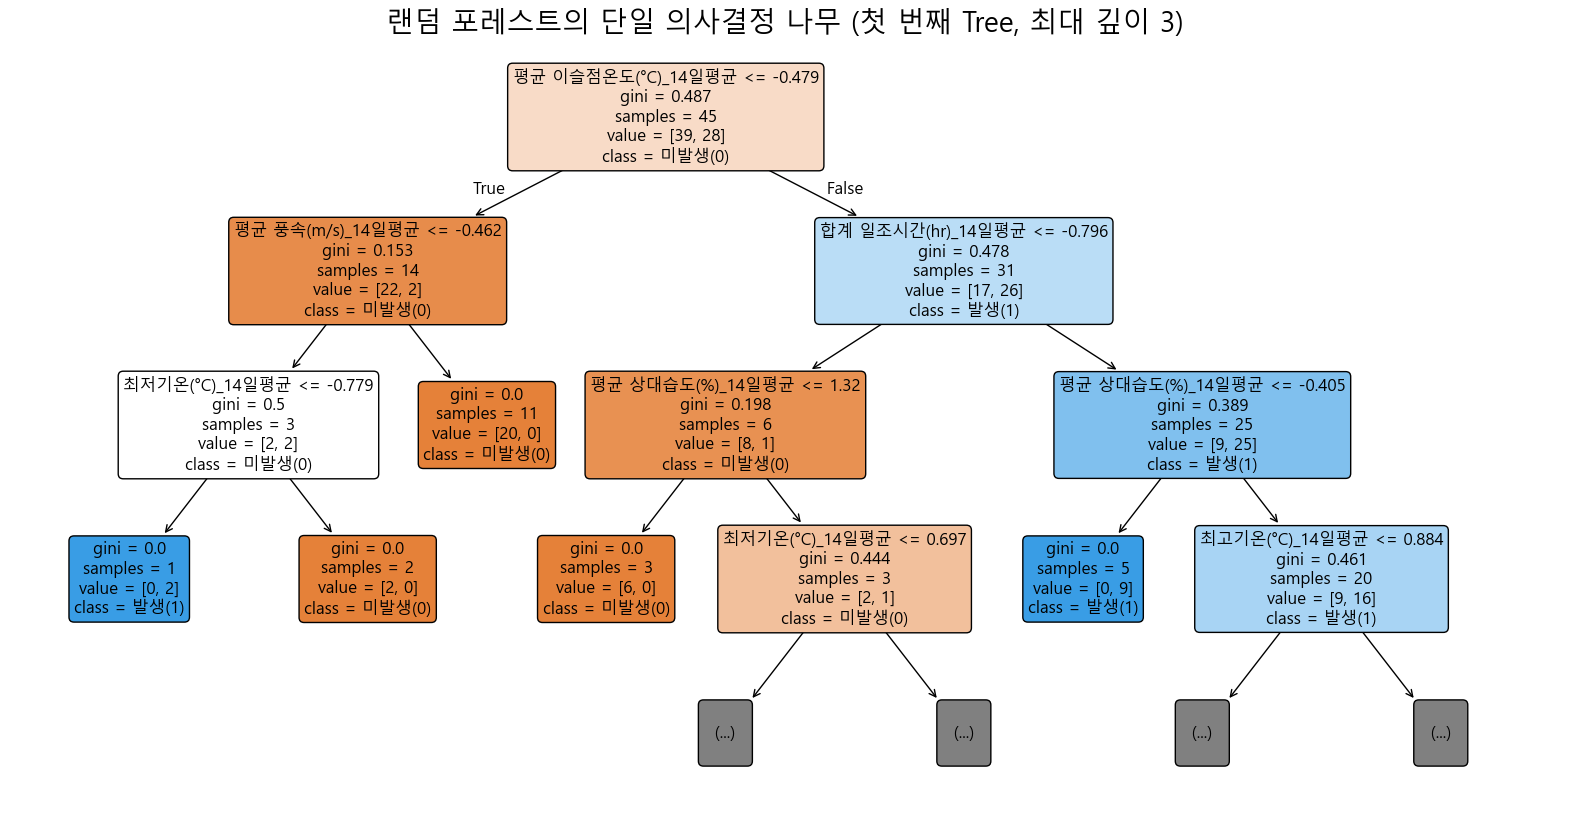

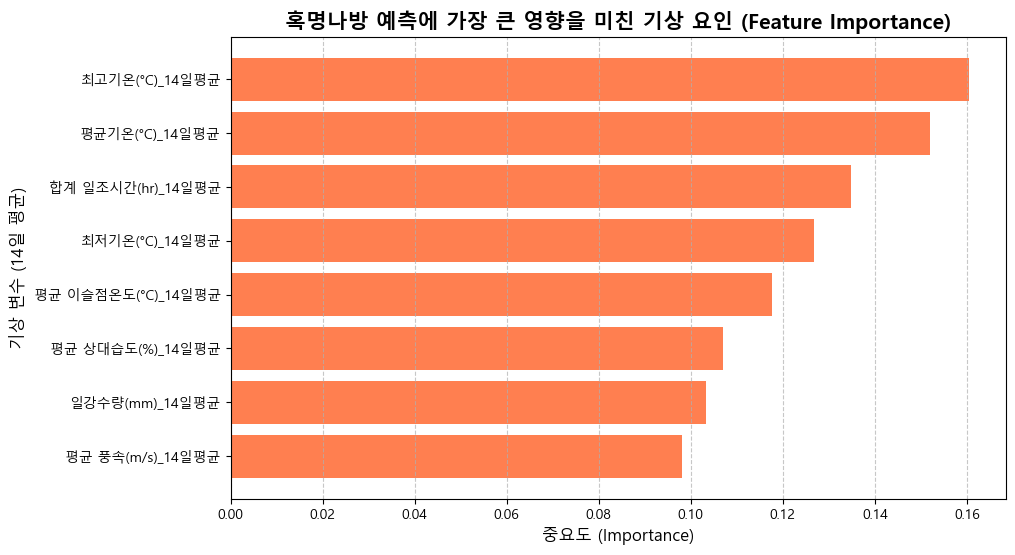

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 0. 한글 폰트 깨짐 방지 설정 (필수!)
import platform
if platform.system() == 'Darwin': # Mac 환경
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows 환경
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# ==========================================
# 1. 단일 의사결정 나무(Tree) 구조 시각화
# ==========================================
plt.figure(figsize=(20, 10))

# 100개의 나무 중 첫 번째 나무(index 0)를 가져와서 봅니다.
# 앙상블 모델 특성상 나무가 너무 깊으면 글씨가 안 보이므로 max_depth=3으로 제한합니다.
estimator = rf_std.estimators_[0] 

plot_tree(estimator, 
          feature_names=X.columns,
          class_names=['미발생(0)', '발생(1)'],
          filled=True,       # 노드 색상 채우기
          rounded=True,      # 둥근 테두리
          max_depth=3,       # 상위 3개 층까지만 출력
          fontsize=12)

plt.title("랜덤 포레스트의 단일 의사결정 나무 (첫 번째 Tree, 최대 깊이 3)", fontsize=20)
plt.show()

print("\n" + "="*60 + "\n")

# ==========================================
# 2. 변수 중요도 (Feature Importance) 시각화
# ==========================================
# 모델이 판단할 때 가장 중요하게 생각한 14일 평균 기상 요인 랭킹
importances = rf_std.feature_importances_
feature_names = X.columns

# 데이터프레임으로 만들고 중요도 순으로 정렬
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='coral')
plt.xlabel('중요도 (Importance)', fontsize=12)
plt.ylabel('기상 변수 (14일 평균)', fontsize=12)
plt.title('혹명나방 예측에 가장 큰 영향을 미친 기상 요인 (Feature Importance)', fontsize=15, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 🌟 2. 타겟 변수 설정 및 결측치(조사 안 한 데이터) 제거
TARGET_PEST = '혹명나방 (피해율)'

# [핵심 수정] 조사를 하지 않아 피해율 데이터가 없는 행은 0으로 채우지 않고 삭제!
pest_df = pest_df.dropna(subset=[TARGET_PEST])

# 삭제 후 남은 '실제 조사 데이터'를 바탕으로 타겟 변수 생성
pest_df['target_binary'] = (pest_df[TARGET_PEST] > 0).astype(int) 
pest_df['target_reg'] = pest_df[TARGET_PEST]

# 3. 지역명 통일화 작업 (나주시 -> 나주, 해남군 -> 해남)
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)

# 기상 데이터 지역 컬럼 지정 (실제 파일의 컬럼명에 맞게 '지점명' 또는 '지역'으로 변경)
WEATHER_REGION_COL = '지점명' 
weather_df['매칭지역'] = weather_df[WEATHER_REGION_COL].astype(str)

# 4. 과거 14일 지역별 평균 데이터 생성
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

valid_features = [f for f in weather_features if f in weather_df.columns]
weather_df[valid_features] = weather_df[valid_features].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df.set_index('일시', inplace=True)

# 지역별로 14일 롤링 평균 계산
rolling_weather = weather_df.groupby('매칭지역')[valid_features].rolling(window=14, min_periods=1).mean().reset_index()
rolling_weather.columns = ['매칭지역', '일시'] + [f"{c}_14일평균" for c in valid_features]

# 5. 예찰 데이터와 기상 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '지역', '매칭지역', 'target_binary', 'target_reg']], 
    rolling_weather, 
    left_on=['조사일', '매칭지역'],               
    right_on=['일시', '매칭지역'],    
    how='inner'
)
merged_df = merged_df.dropna()

# 6. 머신러닝 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '지역', '매칭지역', 'target_binary', 'target_reg'])
y_clf = merged_df['target_binary']
y_reg = merged_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 학습 데이터 수(결측치 정제 후): {len(merged_df)}행 / 투입된 컬럼 수: {X.shape[1]}개\n")
print("🔥 전남 전체 대상 (조사일 기준 엄격 매칭) - 4개 모델 예측 결과 🔥")
print("-" * 65)

# --- 모델 1. Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
lin_pred_reg = lin_reg.predict(X_test_scaled)
lin_pred_clf = (lin_pred_reg > 0).astype(int) 
print(f"1. Linear Regression  | 정확도: {accuracy_score(y_test_clf, lin_pred_clf) * 100:5.2f}% | 재현율(Recall): {recall_score(y_test_clf, lin_pred_clf, zero_division=0) * 100:5.2f}%")

# --- 모델 2. Logistic Regression ---
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train_clf)
log_pred = log_reg.predict(X_test_scaled)
print(f"2. Logistic Regression| 정확도: {accuracy_score(y_test_clf, log_pred) * 100:5.2f}% | 재현율(Recall): {recall_score(y_test_clf, log_pred, zero_division=0) * 100:5.2f}%")

# --- 모델 3. Random Forest ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
rf_pred = rf_clf.predict(X_test_scaled)
print(f"3. Random Forest      | 정확도: {accuracy_score(y_test_clf, rf_pred) * 100:5.2f}% | 재현율(Recall): {recall_score(y_test_clf, rf_pred, zero_division=0) * 100:5.2f}%")

# --- 모델 4. XGBoost ---
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_scaled, y_train_clf)
xgb_pred = xgb_clf.predict(X_test_scaled)
print(f"4. XGBoost            | 정확도: {accuracy_score(y_test_clf, xgb_pred) * 100:5.2f}% | 재현율(Recall): {recall_score(y_test_clf, xgb_pred, zero_division=0) * 100:5.2f}%")
print("-" * 65)

📊 학습 데이터 수(결측치 정제 후): 496행 / 투입된 컬럼 수: 8개

🔥 전남 전체 대상 (조사일 기준 엄격 매칭) - 4개 모델 예측 결과 🔥
-----------------------------------------------------------------
1. Linear Regression  | 정확도: 63.00% | 재현율(Recall): 100.00%
2. Logistic Regression| 정확도: 76.00% | 재현율(Recall): 69.05%
3. Random Forest      | 정확도: 78.00% | 재현율(Recall): 73.81%
4. XGBoost            | 정확도: 77.00% | 재현율(Recall): 64.29%
-----------------------------------------------------------------


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 🌟 2. 타겟 변수 설정 및 결측치 제거 (회귀 전용)
TARGET_PEST = '혹명나방 (피해율)'
pest_df = pest_df.dropna(subset=[TARGET_PEST]) # 결측치 과감히 제거
pest_df['target_reg'] = pest_df[TARGET_PEST]   # 회귀용 연속형 타겟 변수

# 3. 지역명 통일화 작업 (나주시 -> 나주)
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
WEATHER_REGION_COL = '지점명' # 기상청 데이터 컬럼명에 맞게 수정 필요 ('지점명' 또는 '지역')
weather_df['매칭지역'] = weather_df[WEATHER_REGION_COL].astype(str)

# 4. 과거 14일 지역별 기상 데이터 평균 계산
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

valid_features = [f for f in weather_features if f in weather_df.columns]
weather_df[valid_features] = weather_df[valid_features].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df.set_index('일시', inplace=True)

rolling_weather = weather_df.groupby('매칭지역')[valid_features].rolling(window=14, min_periods=1).mean().reset_index()
rolling_weather.columns = ['매칭지역', '일시'] + [f"{c}_14일평균" for c in valid_features]

# 5. 예찰 데이터와 기상 데이터 병합 (지역 1:1 매칭)
merged_df = pd.merge(
    pest_df[['조사일', '지역', '매칭지역', 'target_reg']], 
    rolling_weather, 
    left_on=['조사일', '매칭지역'],               
    right_on=['일시', '매칭지역'],    
    how='inner'
)
merged_df = merged_df.dropna()

# 6. 머신러닝 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '지역', '매칭지역', 'target_reg'])
y_reg = merged_df['target_reg']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 평가지표 출력 함수
def print_regression_metrics(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name:20s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

print(f"📊 학습 데이터 수(결측치 정제 후): {len(merged_df)}행 / 투입된 컬럼 수: {X.shape[1]}개\n")
print("🔥 전남 전체 대상 회귀(Regression) 모델 예측 결과 🔥")
print("   (목표: 피해율 % 정확히 맞추기 / R2는 1에 가까울수록 좋음)")
print("-" * 75)

# --- 모델 1. Linear Regression (선형 회귀) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
lin_pred = lin_reg.predict(X_test_scaled)
print_regression_metrics("1. Linear Regression", y_test_reg, lin_pred)

# --- 모델 2. Ridge Regression (릿지 회귀) ---
ridge_reg = Ridge(random_state=42)
ridge_reg.fit(X_train_scaled, y_train_reg)
ridge_pred = ridge_reg.predict(X_test_scaled)
print_regression_metrics("2. Ridge Regression", y_test_reg, ridge_pred)

# --- 모델 3. Random Forest Regressor (랜덤 포레스트) ---
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_scaled, y_train_reg)
rf_pred = rf_reg.predict(X_test_scaled)
print_regression_metrics("3. Random Forest", y_test_reg, rf_pred)

# --- 모델 4. XGBoost Regressor ---
xgb_reg = XGBRegressor(random_state=42, eval_metric='rmse')
xgb_reg.fit(X_train_scaled, y_train_reg)
xgb_pred = xgb_reg.predict(X_test_scaled)
print_regression_metrics("4. XGBoost", y_test_reg, xgb_pred)
print("-" * 75)

📊 학습 데이터 수(결측치 정제 후): 496행 / 투입된 컬럼 수: 8개

🔥 전남 전체 대상 회귀(Regression) 모델 예측 결과 🔥
   (목표: 피해율 % 정확히 맞추기 / R2는 1에 가까울수록 좋음)
---------------------------------------------------------------------------
1. Linear Regression | RMSE: 0.2139 | MAE: 0.0993 | R2: 0.0086
2. Ridge Regression  | RMSE: 0.2135 | MAE: 0.0983 | R2: 0.0118
3. Random Forest     | RMSE: 0.2345 | MAE: 0.1049 | R2: -0.1922
4. XGBoost           | RMSE: 0.2801 | MAE: 0.1136 | R2: -0.7006
---------------------------------------------------------------------------


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, recall_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 2. 타겟 변수 설정 및 결측치 제거
TARGET_PEST = '혹명나방 (피해율)'
pest_df = pest_df.dropna(subset=[TARGET_PEST]) 
pest_df['target_binary'] = (pest_df[TARGET_PEST] > 0).astype(int) 
pest_df['target_reg'] = pest_df[TARGET_PEST]

# 3. 지역명 통일화
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
WEATHER_REGION_COL = '지점명' # (실제 기상데이터 컬럼명에 맞게 '지역' 또는 '지점명'으로 변경)
weather_df['매칭지역'] = weather_df[WEATHER_REGION_COL].astype(str)

# 4. 과거 14일 지역별 기상 데이터 롤링 평균
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']
valid_features = [f for f in weather_features if f in weather_df.columns]
weather_df[valid_features] = weather_df[valid_features].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df.set_index('일시', inplace=True)

rolling_weather = weather_df.groupby('매칭지역')[valid_features].rolling(window=14, min_periods=1).mean().reset_index()
rolling_weather.columns = ['매칭지역', '일시'] + [f"{c}_14일평균" for c in valid_features]

# 5. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '지역', '매칭지역', 'target_binary', 'target_reg']], 
    rolling_weather, 
    left_on=['조사일', '매칭지역'],               
    right_on=['일시', '매칭지역'],    
    how='inner'
)
merged_df = merged_df.dropna()

# 6. 머신러닝 학습 준비 (데이터 분할)
X = merged_df.drop(columns=['조사일', '일시', '지역', '매칭지역', 'target_binary', 'target_reg'])
y_clf = merged_df['target_binary']
y_reg = merged_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 총 학습 데이터: {len(X_train)}행 / 테스트 데이터: {len(X_test)}행\n")

# =======================================================
# 🔥 1단계 (Stage 1) : 발생 여부(O/X) 분류 모델 학습
# =======================================================
# 로지스틱 회귀는 전체 학습 데이터를 모두 사용하여 O/X를 학습합니다.
stage1_clf = LogisticRegression(max_iter=2000, random_state=42)
stage1_clf.fit(X_train_scaled, y_train_clf)

# =======================================================
# 🔥 2단계 (Stage 2) : 피해율(%) 수치 회귀 모델 학습
# =======================================================
# 회귀 모델은 '실제로 발생했던(target_binary == 1)' 데이터만 추려서 학습합니다!
mask_train_occurred = (y_train_clf == 1)
X_train_stage2 = X_train_scaled[mask_train_occurred]
y_train_stage2 = y_train_reg[mask_train_occurred]

stage2_reg = XGBRegressor(random_state=42, eval_metric='rmse')
stage2_reg.fit(X_train_stage2, y_train_stage2)

print(f"✔️ 2단계 회귀 모델은 전체 중 '발생 데이터' {len(X_train_stage2)}건만 사용하여 집중 학습했습니다.\n")

# =======================================================
# 🔥 두 모델을 결합한 최종 예측 및 평가
# =======================================================
# 1. 테스트 데이터 전체에 대해 1단계 예측(발생 O/X) 수행
pred_stage1_clf = stage1_clf.predict(X_test_scaled)

# 2. 최종 결과를 담을 빈 배열(0으로 채워짐) 생성
final_predictions = np.zeros(len(X_test_scaled))

# 3. 1단계에서 '발생(1)'으로 판정된 데이터만 2단계 회귀 모델에 투입!
mask_test_pred_occurred = (pred_stage1_clf == 1)

if np.sum(mask_test_pred_occurred) > 0:
    # 1단계가 '발생'이라고 한 데이터만 XGBoost에 넣어 피해율(%) 산출 후 업데이트
    pred_stage2_reg = stage2_reg.predict(X_test_scaled[mask_test_pred_occurred])
    final_predictions[mask_test_pred_occurred] = pred_stage2_reg

# --- 결과 출력 ---
print("🔥 Two-Stage (분류 -> 회귀) 결합 모델 최종 결과 🔥")
print("-" * 65)

# 1단계 분류 성능 (방제 알림 기준)
acc = accuracy_score(y_test_clf, pred_stage1_clf) * 100
rec = recall_score(y_test_clf, pred_stage1_clf, zero_division=0) * 100
print(f"[1단계 분류 - 방제 기준] 정확도: {acc:.2f}% | 재현율(Recall): {rec:.2f}%")

# 2단계 결합 후 최종 피해율 예측 성능 (피해액 산출 기준)
rmse = np.sqrt(mean_squared_error(y_test_reg, final_predictions))
mae = mean_absolute_error(y_test_reg, final_predictions)
print(f"[최종 피해율(%) 예측 ] RMSE : {rmse:.4f} | MAE : {mae:.4f}")
print("-" * 65)

# 예측 결과 샘플 확인 (실제 0이 아닌 값이 잘 들어갔는지 확인)
print("\n📝 예측 결과 샘플 10개 (실제 피해율 vs 예측 피해율)")
sample_df = pd.DataFrame({
    '실제 발생여부': y_test_clf[:10].values,
    '실제 피해율(%)': y_test_reg[:10].values,
    '1단계 분류예측': pred_stage1_clf[:10],
    '최종 예측 피해율(%)': final_predictions[:10].round(3)
})
print(sample_df)

📊 총 학습 데이터: 396행 / 테스트 데이터: 100행

✔️ 2단계 회귀 모델은 전체 중 '발생 데이터' 161건만 사용하여 집중 학습했습니다.

🔥 Two-Stage (분류 -> 회귀) 결합 모델 최종 결과 🔥
-----------------------------------------------------------------
[1단계 분류 - 방제 기준] 정확도: 76.00% | 재현율(Recall): 69.05%
[최종 피해율(%) 예측 ] RMSE : 0.2740 | MAE : 0.1092
-----------------------------------------------------------------

📝 예측 결과 샘플 10개 (실제 피해율 vs 예측 피해율)
   실제 발생여부  실제 피해율(%)  1단계 분류예측  최종 예측 피해율(%)
0        0      0.000         0         0.000
1        0      0.000         0         0.000
2        0      0.000         0         0.000
3        0      0.000         0         0.000
4        1      1.333         0         0.000
5        0      0.000         1         0.313
6        1      0.025         1         0.163
7        1      0.057         1         0.020
8        0      0.000         0         0.000
9        0      0.000         0         0.000


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
# r2_score를 추가로 임포트합니다.
from sklearn.metrics import accuracy_score, recall_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 2. 타겟 변수 설정 및 결측치 제거
TARGET_PEST = '혹명나방 (피해율)'
pest_df = pest_df.dropna(subset=[TARGET_PEST]) 
pest_df['target_binary'] = (pest_df[TARGET_PEST] > 0).astype(int) 
pest_df['target_reg'] = pest_df[TARGET_PEST]

# 3. 지역명 통일화
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
WEATHER_REGION_COL = '지점명' 
weather_df['매칭지역'] = weather_df[WEATHER_REGION_COL].astype(str)

# 4. 과거 14일 지역별 기상 데이터 롤링 평균
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']
valid_features = [f for f in weather_features if f in weather_df.columns]
weather_df[valid_features] = weather_df[valid_features].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df.set_index('일시', inplace=True)

rolling_weather = weather_df.groupby('매칭지역')[valid_features].rolling(window=14, min_periods=1).mean().reset_index()
rolling_weather.columns = ['매칭지역', '일시'] + [f"{c}_14일평균" for c in valid_features]

# 5. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '지역', '매칭지역', 'target_binary', 'target_reg']], 
    rolling_weather, 
    left_on=['조사일', '매칭지역'],               
    right_on=['일시', '매칭지역'],    
    how='inner'
)
merged_df = merged_df.dropna()

# 6. 머신러닝 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '지역', '매칭지역', 'target_binary', 'target_reg'])
y_clf = merged_df['target_binary']
y_reg = merged_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =======================================================
# 🔥 1단계 (Stage 1) : 분류 모델 학습
# =======================================================
stage1_clf = LogisticRegression(max_iter=2000, random_state=42)
stage1_clf.fit(X_train_scaled, y_train_clf)

# =======================================================
# 🔥 2단계 (Stage 2) : 회귀 모델 학습 (1인 데이터만)
# =======================================================
mask_train_occurred = (y_train_clf == 1)
X_train_stage2 = X_train_scaled[mask_train_occurred]
y_train_stage2 = y_train_reg[mask_train_occurred]

stage2_reg = XGBRegressor(random_state=42, eval_metric='rmse')
stage2_reg.fit(X_train_stage2, y_train_stage2)

# =======================================================
# 🔥 최종 예측 수행
# =======================================================
pred_stage1_clf = stage1_clf.predict(X_test_scaled)
final_predictions = np.zeros(len(X_test_scaled))
mask_test_pred_occurred = (pred_stage1_clf == 1)

if np.sum(mask_test_pred_occurred) > 0:
    pred_stage2_reg = stage2_reg.predict(X_test_scaled[mask_test_pred_occurred])
    final_predictions[mask_test_pred_occurred] = pred_stage2_reg

# =======================================================
# 🔥 결과 출력 (R2 Score 추가)
# =======================================================
print("🔥 Two-Stage 결합 모델 최종 결과 🔥")
print("-" * 65)

# 1단계 분류 지표
acc = accuracy_score(y_test_clf, pred_stage1_clf) * 100
rec = recall_score(y_test_clf, pred_stage1_clf, zero_division=0) * 100
print(f"[1단계 분류 - 방제 기준] 정확도: {acc:.2f}% | 재현율(Recall): {rec:.2f}%")

# 2단계 회귀 지표 (최종 결과 기준)
rmse = np.sqrt(mean_squared_error(y_test_reg, final_predictions))
mae = mean_absolute_error(y_test_reg, final_predictions)
# 추가된 부분: 최종 예측 결과에 대한 R2 Score 계산
r2 = r2_score(y_test_reg, final_predictions)

print(f"[최종 피해율(%) 예측 ] RMSE : {rmse:.4f} | MAE : {mae:.4f}")
print(f"[최종 피해율(%) 예측 ] R2 Score : {r2:.4f}")
print("-" * 65)

# 2단계 전용 지표 (발생한 건에 대해서만 XGBoost가 얼마나 잘 맞췄는지 궁금할 때)
actual_occurred_mask = (y_test_clf == 1)
if np.sum(actual_occurred_mask) > 0:
    y_test_actual_occurred = y_test_reg[actual_occurred_mask]
    # 실제 발생한 건들을 2단계 모델에 넣어봄
    pred_only_stage2 = stage2_reg.predict(X_test_scaled[actual_occurred_mask])
    r2_stage2_only = r2_score(y_test_actual_occurred, pred_only_stage2)
    print(f"[참고: Stage 2 전용] 발생 데이터에 대한 XGBoost R2 : {r2_stage2_only:.4f}")

🔥 Two-Stage 결합 모델 최종 결과 🔥
-----------------------------------------------------------------
[1단계 분류 - 방제 기준] 정확도: 76.00% | 재현율(Recall): 69.05%
[최종 피해율(%) 예측 ] RMSE : 0.2740 | MAE : 0.1092
[최종 피해율(%) 예측 ] R2 Score : -0.6266
-----------------------------------------------------------------
[참고: Stage 2 전용] 발생 데이터에 대한 XGBoost R2 : -0.2734


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, recall_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기 (파일 경로는 그대로 유지)
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 2. 타겟 설정 및 결측치 제거
TARGET_PEST = '혹명나방 (피해율)'
pest_df = pest_df.dropna(subset=[TARGET_PEST])
pest_df['target_binary'] = (pest_df[TARGET_PEST] > 0).astype(int)
pest_df['target_reg'] = pest_df[TARGET_PEST]

# 3. 지역명 통일 (나주시 -> 나주)
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
WEATHER_REGION_COL = '지점명' # 기상청 파일 확인 필요
weather_df['매칭지역'] = weather_df[WEATHER_REGION_COL].astype(str)

# 4. 기상 데이터 14일 평균 처리
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']
valid_features = [f for f in weather_features if f in weather_df.columns]
weather_df[valid_features] = weather_df[valid_features].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df.set_index('일시', inplace=True)
rolling_weather = weather_df.groupby('매칭지역')[valid_features].rolling(window=14, min_periods=1).mean().reset_index()
rolling_weather.columns = ['매칭지역', '일시'] + [f"{c}_14일평균" for c in valid_features]

# 5. 병합
merged_df = pd.merge(
    pest_df[['조사일', '지역', '매칭지역', 'target_binary', 'target_reg']], 
    rolling_weather, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
)
merged_df = merged_df.dropna()

# 6. 학습 데이터 준비
X = merged_df.drop(columns=['조사일', '일시', '지역', '매칭지역', 'target_binary', 'target_reg'])
y_clf = merged_df['target_binary']
y_reg = merged_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =======================================================
# 🔥 Stage 1: 분류 (Logistic Regression)
# =======================================================
stage1_clf = LogisticRegression(max_iter=2000, random_state=42)
stage1_clf.fit(X_train_scaled, y_train_clf)

# =======================================================
# 🔥 Stage 2: 회귀 (Random Forest Regressor로 변경)
# =======================================================
# 발생한 데이터(1)만 추출
mask_train_occurred = (y_train_clf == 1)
X_train_stage2 = X_train_scaled[mask_train_occurred]
y_train_stage2 = y_train_reg[mask_train_occurred]

# 데이터가 적을 때는 트리의 깊이를 제한(max_depth)하는 것이 과적합 방지에 매우 중요합니다.
stage2_reg = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
stage2_reg.fit(X_train_stage2, y_train_stage2)

print(f"✔️ Stage 2 (RF) 학습 데이터 수: {len(X_train_stage2)}건\n")

# =======================================================
# 🔥 최종 예측 (임계값 조정 적용)
# =======================================================
# 단순 predict 대신 predict_proba를 써서 확률을 가져옵니다.
proba_stage1 = stage1_clf.predict_proba(X_test_scaled)[:, 1]

# 🌟 임계값 조정: 0.5가 아니라 0.3으로 낮춰서 "조금만 위험해도 방제 알림"
threshold = 0.3 
pred_stage1_custom = (proba_stage1 >= threshold).astype(int)

final_predictions = np.zeros(len(X_test_scaled))
mask_test_pred_occurred = (pred_stage1_custom == 1)

if np.sum(mask_test_pred_occurred) > 0:
    pred_stage2_reg = stage2_reg.predict(X_test_scaled[mask_test_pred_occurred])
    final_predictions[mask_test_pred_occurred] = pred_stage2_reg

# =======================================================
# 🔥 결과 출력
# =======================================================
print(f"🔥 Stage 2: Random Forest / 임계값: {threshold} 적용 결과 🔥")
print("-" * 65)

# 1단계 지표 (재현율 확인이 중요!)
acc = accuracy_score(y_test_clf, pred_stage1_custom) * 100
rec = recall_score(y_test_clf, pred_stage1_custom, zero_division=0) * 100
print(f"[1단계 분류] 정확도: {acc:.2f}% | 재현율(Recall): {rec:.2f}%")

# 최종 지표
rmse = np.sqrt(mean_squared_error(y_test_reg, final_predictions))
r2 = r2_score(y_test_reg, final_predictions)
print(f"[최종 예측] RMSE: {rmse:.4f} | R2 Score: {r2:.4f}")
print("-" * 65)

# 실제 발생 건에 대한 예측력 확인
actual_mask = (y_test_clf == 1)
if np.sum(actual_mask) > 0:
    r2_pure = r2_score(y_test_reg[actual_mask], stage2_reg.predict(X_test_scaled[actual_mask]))
    print(f"💡 (참고) 실제 발생 상황에서 RF의 수치 예측 R2: {r2_pure:.4f}")

✔️ Stage 2 (RF) 학습 데이터 수: 161건

🔥 Stage 2: Random Forest / 임계값: 0.3 적용 결과 🔥
-----------------------------------------------------------------
[1단계 분류] 정확도: 75.00% | 재현율(Recall): 92.86%
[최종 예측] RMSE: 0.2719 | R2 Score: -0.6017
-----------------------------------------------------------------
💡 (참고) 실제 발생 상황에서 RF의 수치 예측 R2: -0.1762


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, recall_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기 및 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])
pest_df['target_binary'] = (pest_df['혹명나방 (피해율)'] > 0).astype(int)
pest_df['target_reg'] = pest_df['혹명나방 (피해율)']

# 지역명 매칭
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
WEATHER_REGION_COL = '지점명' 
weather_df['매칭지역'] = weather_df[WEATHER_REGION_COL].astype(str)

# 2. 파생 변수 생성 (통계량 확장)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df.set_index('일시', inplace=True)

weather_grouped = weather_df.groupby('매칭지역')

# 14일간의 평균, 최대, 합계 산출
roll_mean = weather_grouped[['평균기온(°C)', '평균 상대습도(%)', '평균 풍속(m/s)']].rolling(14, min_periods=1).mean().reset_index()
roll_max  = weather_grouped[['최고기온(°C)', '평균 상대습도(%)']].rolling(14, min_periods=1).max().reset_index()
roll_sum  = weather_grouped[['일강수량(mm)', '합계 일조시간(hr)']].rolling(14, min_periods=1).sum().reset_index()

weather_fe = roll_mean.copy()
weather_fe['최고기온_14일max'] = roll_max['최고기온(°C)']
weather_fe['상대습도_14일max'] = roll_max['평균 상대습도(%)']
weather_fe['강수량_14일sum'] = roll_sum['일강수량(mm)']
weather_fe['일조시간_14일sum'] = roll_sum['합계 일조시간(hr)']

# 3. 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'target_binary', 'target_reg']], 
    weather_fe, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 4. 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '매칭지역', 'target_binary', 'target_reg'])
y_clf = merged_df['target_binary']
y_reg = merged_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =======================================================
# 🔥 Stage 1: 분류 (Logistic Regression)
# =======================================================
stage1_clf = LogisticRegression(max_iter=2000, random_state=42)
stage1_clf.fit(X_train_scaled, y_train_clf)

# =======================================================
# 🔥 Stage 2: 회귀 (Ridge + 로그 변환)
# =======================================================
mask_train = (y_train_clf == 1)
X_train_s2 = X_train_scaled[mask_train]
y_train_s2_log = np.log1p(y_train_reg[mask_train]) 

stage2_ridge = Ridge(alpha=1.0, random_state=42)
stage2_ridge.fit(X_train_s2, y_train_s2_log)

# =======================================================
# 🔥 최종 예측 및 평가
# =======================================================
proba_s1 = stage1_clf.predict_proba(X_test_scaled)[:, 1]
# 재현율 확보를 위해 임계값 0.3 적용
pred_s1_custom = (proba_s1 >= 0.3).astype(int)

final_predictions = np.zeros(len(X_test_scaled))
mask_test_occur = (pred_s1_custom == 1)

if np.sum(mask_test_occur) > 0:
    pred_log = stage2_ridge.predict(X_test_scaled[mask_test_occur])
    final_predictions[mask_test_occur] = np.expm1(pred_log)

# --- 결과 출력 (에러 해결 부분) ---
print(f"📊 Stage 2 (Ridge) 학습 데이터: {len(X_train_s2)}건")
print("-" * 65)
print(f"[1단계 분류] 정확도: {accuracy_score(y_test_clf, pred_s1_custom)*100:.2f}% | 재현율: {recall_score(y_test_clf, pred_s1_custom)*100:.2f}%")

# squared=False 대신 np.sqrt()를 사용하여 RMSE 계산
rmse = np.sqrt(mean_squared_error(y_test_reg, final_predictions))
r2 = r2_score(y_test_reg, final_predictions)

print(f"[최종 예측] RMSE: {rmse:.4f} | R2 Score: {r2:.4f}")
print("-" * 65)

📊 Stage 2 (Ridge) 학습 데이터: 161건
-----------------------------------------------------------------
[1단계 분류] 정확도: 75.00% | 재현율: 92.86%
[최종 예측] RMSE: 0.2307 | R2 Score: -0.1535
-----------------------------------------------------------------


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# 🌟 [전략 1] 피해율 등급화 (Binning)
# 0: 무피해, 1: 경미(0~1%), 2: 주의(1~5%), 3: 심각(5% 초과)
def categorize_damage(rate):
    if rate == 0: return 0
    elif rate <= 1.0: return 1
    elif rate <= 5.0: return 2
    else: return 3

pest_df['damage_grade'] = pest_df['혹명나방 (피해율)'].apply(categorize_damage)

# 지역 매칭 준비
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# 🌟 [전략 2] 기상 변수 고도화 (에러 해결 & 방식 최적화)
# 결측치 0으로 채우기
weather_cols = ['평균기온(°C)', '최고기온(°C)', '평균 상대습도(%)', '일강수량(mm)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

# 정렬 및 인덱스 초기화 (롤링을 위한 필수 작업)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)

# 폭염 여부를 나타내는 임시 컬럼 생성 (33도 이상)
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

# 💡 apply를 쓰지 않고 그룹화 후 롤링 결과를 바로 컬럼에 할당 (에러 원천 차단)
wg = weather_df.groupby('매칭지역')

weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_max']      = wg['평균 상대습도(%)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['강수량_sum']     = wg['일강수량(mm)'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

# 병합을 위해 필요한 파생변수만 분리
w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '습도_mean', '습도_max', '강수량_sum', '폭염일수']]

# 3. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'damage_grade', '혹명나방 (피해율)']], 
    w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 4. 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '매칭지역', 'damage_grade', '혹명나방 (피해율)'])
y = merged_df['damage_grade']

# stratify=y 를 통해 클래스(등급) 비율이 학습/테스트 셋에 골고루 섞이게 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. 모델 학습 (Random Forest Classifier)
model = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# 6. 경제 효과 산출 시뮬레이션
y_pred = model.predict(X_test_scaled)

# 각 등급별 실제 평균 피해율 계산 (학습 데이터 전체 기준)
grade_means = merged_df.groupby('damage_grade')['혹명나방 (피해율)'].mean().to_dict()

print("🔥 피해 등급 기반 경제 효과 산출 모델 🔥")
print("-" * 65)
print(f"모델 정확도: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print("[등급별 예측 성능 요약]")
# zero_division=0 옵션 추가로 경고문 방지
# 기존 코드의 에러 발생 부분:
# print(classification_report(y_test, y_pred, target_names=['무피해', '경미', '주의', '심각'], zero_division=0))

# ----------------------------------------------------
# ✅ 아래 코드로 변경해 주세요:
# ----------------------------------------------------
print(classification_report(y_test, y_pred, 
                            labels=[0, 1, 2, 3], # 이 부분이 핵심입니다!
                            target_names=['무피해', '경미', '주의', '심각'], 
                            zero_division=0))

# ==========================================
# 💰 경제적 손실 시나리오 적용
# ==========================================
RICE_PRICE_PER_KG = 2500  # 쌀 가격 (kg당)
YIELD_PER_1000M2 = 530    # 1000m2(단보)당 수확량 (kg)
COST_CONTROL = 50000      # 1000m2당 1회 방제 비용 (약제+인건비 등)

def calculate_benefit(pred_grade):
    # 예측된 등급의 평균 피해율(%)을 소수로 변환 (예: 5% -> 0.05)
    exp_rate = grade_means.get(pred_grade, 0) / 100
    
    # 잠재적 피해액 = 수확량 * 쌀가격 * 피해율
    potential_loss = YIELD_PER_1000M2 * RICE_PRICE_PER_KG * exp_rate
    
    # 방제 이득 = (막아낸 피해액) - (방제 비용)
    net_benefit = potential_loss - COST_CONTROL
    return potential_loss, net_benefit

# 테스트 셋 샘플 추출 후 결과 저장
results = []
for i in range(min(10, len(y_test))): # 최대 10개까지만 출력
    loss, benefit = calculate_benefit(y_pred[i])
    results.append({
        '실제등급': y_test.iloc[i],
        '예측등급': y_pred[i],
        '적용피해율': f"{grade_means.get(y_pred[i], 0):.2f}%",
        '예상피해액': f"{int(loss):,}원",
        '방제이득': f"{int(benefit):,}원"
    })

print("\n💰 방제 경제 효과 시뮬레이션 샘플 (1,000m² 기준)")
print(pd.DataFrame(results))

🔥 피해 등급 기반 경제 효과 산출 모델 🔥
-----------------------------------------------------------------
모델 정확도: 73.00%

[등급별 예측 성능 요약]
              precision    recall  f1-score   support

         무피해       0.77      0.80      0.78        59
          경미       0.67      0.67      0.67        39
          주의       0.00      0.00      0.00         2
          심각       0.00      0.00      0.00         0

    accuracy                           0.73       100
   macro avg       0.36      0.37      0.36       100
weighted avg       0.71      0.73      0.72       100


💰 방제 경제 효과 시뮬레이션 샘플 (1,000m² 기준)
   실제등급  예측등급  적용피해율   예상피해액      방제이득
0     0     0  0.00%      0원  -50,000원
1     1     0  0.00%      0원  -50,000원
2     0     1  0.09%  1,143원  -48,856원
3     1     1  0.09%  1,143원  -48,856원
4     0     0  0.00%      0원  -50,000원
5     0     0  0.00%      0원  -50,000원
6     0     0  0.00%      0원  -50,000원
7     1     1  0.09%  1,143원  -48,856원
8     0     0  0.00%      0원  -50,000원
9     1     1  0.09

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# ==========================================================
# 🌟 [핵심 변경] 주관적 배제, 데이터 기반(분위수) 객관적 등급화
# ==========================================================
# 0이 아닌 실제 피해 발생 데이터만 추출
positive_damage = pest_df[pest_df['혹명나방 (피해율)'] > 0]['혹명나방 (피해율)']

# 피해 발생 데이터를 정확히 3등분(33.3%, 66.7%) 하는 경계값 계산
p33 = np.percentile(positive_damage, 33.33)
p67 = np.percentile(positive_damage, 66.67)

print("📊 [데이터가 스스로 찾은 객관적 등급 기준]")
print(f" - 정상 : 0%")
print(f" - 경미 : 0% 초과 ~ {p33:.4f}% 이하")
print(f" - 주의 : {p33:.4f}% 초과 ~ {p67:.4f}% 이하")
print(f" - 심각 : {p67:.4f}% 초과")
print("-" * 65)

# 동적 기준을 적용하는 함수
def categorize_damage_objective(rate):
    if rate == 0: return 0
    elif rate <= p33: return 1
    elif rate <= p67: return 2
    else: return 3

pest_df['damage_grade'] = pest_df['혹명나방 (피해율)'].apply(categorize_damage_objective)

# 지역 매칭
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# 2. 기상 변수 고도화 (에러 없는 빠른 방식)
weather_cols = ['평균기온(°C)', '최고기온(°C)', '평균 상대습도(%)', '일강수량(mm)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_max']      = wg['평균 상대습도(%)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['강수량_sum']     = wg['일강수량(mm)'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '습도_mean', '습도_max', '강수량_sum', '폭염일수']]

# 3. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'damage_grade', '혹명나방 (피해율)']], 
    w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 4. 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '매칭지역', 'damage_grade', '혹명나방 (피해율)'])
y = merged_df['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. 모델 학습
model = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# 6. 결과 평가 및 경제 효과 시뮬레이션
y_pred = model.predict(X_test_scaled)

# 모델이 등급을 예측했을 때 적용할 "해당 등급의 실제 평균 피해율" 계산
grade_means = merged_df.groupby('damage_grade')['혹명나방 (피해율)'].mean().to_dict()

print(f"모델 정확도: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print("[등급별 예측 성능 요약]")
# 타겟 클래스가 부족해도 에러가 나지 않도록 labels 파라미터 명시
print(classification_report(y_test, y_pred, labels=[0, 1, 2, 3], target_names=['정상', '경미', '주의', '심각'], zero_division=0))

# ==========================================
# 💰 경제적 손실 시나리오 적용
# ==========================================
RICE_PRICE_PER_KG = 2500  # 쌀 가격 (kg당)
YIELD_PER_1000M2 = 530    # 1000m2(단보)당 수확량 (kg)
COST_CONTROL = 50000      # 1000m2당 방제 비용

def calculate_benefit(pred_grade):
    exp_rate = grade_means.get(pred_grade, 0) / 100
    potential_loss = YIELD_PER_1000M2 * RICE_PRICE_PER_KG * exp_rate
    net_benefit = potential_loss - COST_CONTROL
    return potential_loss, net_benefit

results = []
for i in range(min(10, len(y_test))):
    loss, benefit = calculate_benefit(y_pred[i])
    results.append({
        '실제등급': ['정상', '경미', '주의', '심각'][y_test.iloc[i]],
        '예측등급': ['정상', '경미', '주의', '심각'][y_pred[i]],
        '적용피해율': f"{grade_means.get(y_pred[i], 0):.4f}%",
        '예상피해액': f"{int(loss):,}원",
        '방제이득': f"{int(benefit):,}원"
    })

print("\n💰 방제 경제 효과 시뮬레이션 샘플 (1,000m² 기준)")
print(pd.DataFrame(results))

📊 [데이터가 스스로 찾은 객관적 등급 기준]
 - 정상 : 0%
 - 경미 : 0% 초과 ~ 0.0096% 이하
 - 주의 : 0.0096% 초과 ~ 0.0520% 이하
 - 심각 : 0.0520% 초과
-----------------------------------------------------------------
모델 정확도: 57.00%

[등급별 예측 성능 요약]
              precision    recall  f1-score   support

          정상       0.74      0.78      0.76        59
          경미       0.00      0.00      0.00         9
          주의       0.45      0.31      0.37        16
          심각       0.23      0.38      0.29        16

    accuracy                           0.57       100
   macro avg       0.36      0.37      0.35       100
weighted avg       0.55      0.57      0.55       100


💰 방제 경제 효과 시뮬레이션 샘플 (1,000m² 기준)
  실제등급 예측등급    적용피해율   예상피해액      방제이득
0   정상   정상  0.0000%      0원  -50,000원
1   주의   정상  0.0000%      0원  -50,000원
2   정상   주의  0.0274%    363원  -49,636원
3   주의   주의  0.0274%    363원  -49,636원
4   정상   정상  0.0000%      0원  -50,000원
5   정상   정상  0.0000%      0원  -50,000원
6   정상   정상  0.0000%      0원  -50,000원
7   주의 

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# ==========================================================
# 🌟 [전략 1] 데이터 기반(분위수) 객관적 등급화 (이전과 동일)
# ==========================================================
positive_damage = pest_df[pest_df['혹명나방 (피해율)'] > 0]['혹명나방 (피해율)']
p33 = np.percentile(positive_damage, 33.33)
p67 = np.percentile(positive_damage, 66.67)

def categorize_damage_objective(rate):
    if rate == 0: return 0
    elif rate <= p33: return 1
    elif rate <= p67: return 2
    else: return 3

pest_df['damage_grade'] = pest_df['혹명나방 (피해율)'].apply(categorize_damage_objective)

# 지역 매칭
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 [전략 2] 14일치 데이터 전체 펼치기 (Unrolling)
# ==========================================================
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

valid_features = [c for c in weather_features if c in weather_df.columns]
weather_df[valid_features] = weather_df[valid_features].fillna(0)

# 정렬은 필수 (시간의 흐름대로 과거 데이터를 가져오기 위함)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
wg = weather_df.groupby('매칭지역')

shifted_cols = []
# 1일 전(D-1)부터 14일 전(D-14)까지의 데이터를 각각의 컬럼으로 생성
for i in range(1, 15):
    for col in valid_features:
        shifted_series = wg[col].shift(i).rename(f'{col}_D-{i}')
        shifted_cols.append(shifted_series)

# 원본 날짜/지역 데이터와 14일치 과거 데이터를 병합
weather_unrolled = pd.concat([weather_df[['매칭지역', '일시']]] + shifted_cols, axis=1)

# 3. 예찰 데이터와 기상 데이터 병합 (결측치가 생긴 앞부분 14일은 자동으로 떨어져 나감)
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'damage_grade']], 
    weather_unrolled, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 4. 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '매칭지역', 'damage_grade'])
y = merged_df['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 최종 학습 데이터: {len(X_train)}행 / 투입된 특징(Feature) 수: {X.shape[1]}개\n")
print("🔥 14일 전체 데이터 투입 - 3개 분류 모델 성능 비교 🔥")
print("=" * 65)

# ==========================================================
# 🌟 [전략 3] 3가지 분류 모델 학습 및 평가
# ==========================================================
models = {
    "1. Logistic Regression": LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced'),
    "2. Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, class_weight='balanced'),
    "3. XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss') 
    # XGBoost는 다중 분류(0,1,2,3)를 자동으로 인식하여 처리합니다.
}

for name, model in models.items():
    # 모델 학습
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_pred = model.predict(X_test_scaled)
    
    # 평가 출력
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"\n▶ {name} (정확도: {acc:.2f}%)")
    print("-" * 65)
    print(classification_report(y_test, y_pred, 
                                labels=[0, 1, 2, 3], 
                                target_names=['정상(0)', '경미(1)', '주의(2)', '심각(3)'], 
                                zero_division=0))
print("=" * 65)

📊 최종 학습 데이터: 396행 / 투입된 특징(Feature) 수: 112개

🔥 14일 전체 데이터 투입 - 3개 분류 모델 성능 비교 🔥

▶ 1. Logistic Regression (정확도: 51.00%)
-----------------------------------------------------------------
              precision    recall  f1-score   support

       정상(0)       0.83      0.68      0.75        59
       경미(1)       0.15      0.22      0.18         9
       주의(2)       0.19      0.25      0.22        16
       심각(3)       0.28      0.31      0.29        16

    accuracy                           0.51       100
   macro avg       0.36      0.37      0.36       100
weighted avg       0.58      0.51      0.54       100


▶ 2. Random Forest (정확도: 53.00%)
-----------------------------------------------------------------
              precision    recall  f1-score   support

       정상(0)       0.80      0.75      0.77        59
       경미(1)       0.00      0.00      0.00         9
       주의(2)       0.19      0.25      0.22        16
       심각(3)       0.26      0.31      0.29        16

    acc

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# ==========================================================
# 🌟 객관적 등급화 (0:정상, 1:경미, 2:주의, 3:심각)
# ==========================================================
positive_damage = pest_df[pest_df['혹명나방 (피해율)'] > 0]['혹명나방 (피해율)']
p33 = np.percentile(positive_damage, 33.33)
p67 = np.percentile(positive_damage, 66.67)

def categorize_damage_objective(rate):
    if rate == 0: return 0
    elif rate <= p33: return 1
    elif rate <= p67: return 2
    else: return 3

pest_df['damage_grade'] = pest_df['혹명나방 (피해율)'].apply(categorize_damage_objective)

# 지역 매칭 준비
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 14일 기상 데이터 '요약 (평균/최대/합계)' 
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '평균 상대습도(%)', '일강수량(mm)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_max']      = wg['평균 상대습도(%)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['강수량_sum']     = wg['일강수량(mm)'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '습도_mean', '습도_max', '강수량_sum', '폭염일수']]

# 3. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'damage_grade']], 
    w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 4. 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '매칭지역', 'damage_grade'])
y = merged_df['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 최종 학습 데이터: {len(X_train)}행 / 투입된 특징(Feature) 수: {X.shape[1]}개\n")
print("🔥 14일 요약(평균/최대/합계) 데이터 투입 - 3개 분류 모델 성능 비교 🔥")
print("=" * 65)

# ==========================================================
# 🌟 3가지 분류 모델 학습 및 평가
# ==========================================================
models = {
    "1. Logistic Regression": LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced'),
    "2. Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, class_weight='balanced'),
    "3. XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss') 
}

for name, model in models.items():
    # 모델 학습
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_pred = model.predict(X_test_scaled)
    
    # 평가 출력
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"\n▶ {name} (정확도: {acc:.2f}%)")
    print("-" * 65)
    # 클래스가 4개(0,1,2,3)임을 명시하여 에러 방지
    print(classification_report(y_test, y_pred, 
                                labels=[0, 1, 2, 3], 
                                target_names=['정상(0)', '경미(1)', '주의(2)', '심각(3)'], 
                                zero_division=0))
print("=" * 65)

📊 최종 학습 데이터: 396행 / 투입된 특징(Feature) 수: 6개

🔥 14일 요약(평균/최대/합계) 데이터 투입 - 3개 분류 모델 성능 비교 🔥

▶ 1. Logistic Regression (정확도: 50.00%)
-----------------------------------------------------------------
              precision    recall  f1-score   support

       정상(0)       0.75      0.68      0.71        59
       경미(1)       0.12      0.11      0.12         9
       주의(2)       0.20      0.12      0.15        16
       심각(3)       0.24      0.44      0.31        16

    accuracy                           0.50       100
   macro avg       0.33      0.34      0.32       100
weighted avg       0.53      0.50      0.51       100


▶ 2. Random Forest (정확도: 57.00%)
-----------------------------------------------------------------
              precision    recall  f1-score   support

       정상(0)       0.74      0.78      0.76        59
       경미(1)       0.00      0.00      0.00         9
       주의(2)       0.45      0.31      0.37        16
       심각(3)       0.23      0.38      0.29        16


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# ==========================================================
# 🌟 객관적 등급화 (0:정상, 1:경미, 2:주의, 3:심각)
# ==========================================================
positive_damage = pest_df[pest_df['혹명나방 (피해율)'] > 0]['혹명나방 (피해율)']
p33 = np.percentile(positive_damage, 33.33)
p67 = np.percentile(positive_damage, 66.67)

def categorize_damage_objective(rate):
    if rate == 0: return 0
    elif rate <= p33: return 1
    elif rate <= p67: return 2
    else: return 3

pest_df['damage_grade'] = pest_df['혹명나방 (피해율)'].apply(categorize_damage_objective)

# 지역 매칭 준비
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 14일 기상 데이터 피처 엔지니어링 (요청사항 완벽 반영)
# ==========================================================
# 사용할 필수 기상 컬럼 정의 (최저기온, 일조시간 추가)
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', '일강수량(mm)', '합계 일조시간(hr)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

# 롤링을 위해 지역 및 날짜 순으로 정렬
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)

# 폭염 변수 유지
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

# 💡 피처(특징) 계산 (습도 max 제거, 강수량/일조시간 평균으로 변경)
wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['최저기온_mean'] = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)  # 추가
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']   = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)     # sum -> mean 변경
weather_df['일조시간_mean'] = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True) # 합계 -> mean 변경
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

# 병합할 최종 피처 선택
w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '최저기온_mean', 
                         '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']]

# 3. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'damage_grade']], 
    w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 4. 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '매칭지역', 'damage_grade'])
y = merged_df['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 최종 학습 데이터: {len(X_train)}행 / 투입된 특징(Feature) 수: {X.shape[1]}개\n")
print("🔥 개선된 14일 기상 요약 데이터 투입 - 3개 분류 모델 성능 비교 🔥")
print("=" * 65)

# ==========================================================
# 🌟 3가지 분류 모델 학습 및 평가
# ==========================================================
models = {
    "1. Logistic Regression": LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced'),
    "2. Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, class_weight='balanced'),
    "3. XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss') 
}

for name, model in models.items():
    # 모델 학습
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_pred = model.predict(X_test_scaled)
    
    # 평가 출력
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"\n▶ {name} (정확도: {acc:.2f}%)")
    print("-" * 65)
    print(classification_report(y_test, y_pred, 
                                labels=[0, 1, 2, 3], 
                                target_names=['정상(0)', '경미(1)', '주의(2)', '심각(3)'], 
                                zero_division=0))
print("=" * 65)

📊 최종 학습 데이터: 396행 / 투입된 특징(Feature) 수: 7개

🔥 개선된 14일 기상 요약 데이터 투입 - 3개 분류 모델 성능 비교 🔥

▶ 1. Logistic Regression (정확도: 53.00%)
-----------------------------------------------------------------
              precision    recall  f1-score   support

       정상(0)       0.82      0.68      0.74        59
       경미(1)       0.19      0.33      0.24         9
       주의(2)       0.20      0.12      0.15        16
       심각(3)       0.32      0.50      0.39        16

    accuracy                           0.53       100
   macro avg       0.38      0.41      0.38       100
weighted avg       0.58      0.53      0.55       100


▶ 2. Random Forest (정확도: 52.00%)
-----------------------------------------------------------------
              precision    recall  f1-score   support

       정상(0)       0.70      0.73      0.72        59
       경미(1)       0.00      0.00      0.00         9
       주의(2)       0.21      0.19      0.20        16
       심각(3)       0.25      0.38      0.30        16

  

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore') # 반복문 출력 깔끔하게 하기 위해 경고 숨김

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# 2. 14일 기상 데이터 피처 생성 (한 번만 수행하여 속도 최적화)
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', '일강수량(mm)', '합계 일조시간(hr)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['최저기온_mean'] = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']   = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean'] = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '최저기온_mean', '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']]

# 예찰 데이터 중 (피해율)이 들어간 모든 컬럼 찾기
target_diseases = [col for col in pest_df.columns if '(피해율)' in col]

# 결과 저장을 위한 리스트
all_results = []

print("⏳ 모든 병해충 모델 스캔 중... 잠시만 기다려주세요.\n")

# 3. 모든 병해충에 대해 반복 학습 및 평가
for target in target_diseases:
    # 해당 병해충에 결측치가 없는 데이터만 추출
    df_subset = pest_df[['조사일', '매칭지역', target]].dropna()
    
    # 병합
    merged_df = pd.merge(
        df_subset, w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
    ).dropna()
    
    if len(merged_df) < 50:
        continue # 데이터가 너무 적은 병은 제외
        
    # O/X 이진 분류 타겟 생성
    merged_df['target_bin'] = (merged_df[target] > 0).astype(int)
    
    # 클래스가 1개뿐이면(모두 0이거나 모두 1) 분할 및 학습 불가 -> 제외
    if merged_df['target_bin'].nunique() < 2:
        continue
        
    occur_rate = merged_df['target_bin'].mean() * 100
    
    # 너무 극단적인 데이터(발생률 1% 미만 등)는 제외하거나 유지 (일단 유지)
    feature_cols = ['평균기온_mean', '최고기온_max', '최저기온_mean', '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']
    X = merged_df[feature_cols]
    y = merged_df['target_bin']
    
    # 데이터 분할
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except ValueError:
        # 데이터 부족으로 stratify 실패 시 일반 분할
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 모델 정의
    lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
    xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
    
    # 학습 및 정확도 측정
    lr_model.fit(X_train_scaled, y_train)
    rf_model.fit(X_train_scaled, y_train)
    xgb_model.fit(X_train_scaled, y_train)
    
    lr_acc = accuracy_score(y_test, lr_model.predict(X_test_scaled)) * 100
    rf_acc = accuracy_score(y_test, rf_model.predict(X_test_scaled)) * 100
    xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test_scaled)) * 100
    
    # 병해충 이름 깔끔하게 정리 (예: 혹명나방 (피해율) -> 혹명나방)
    clean_name = target.replace(' (피해율)', '')
    
    all_results.append({
        '병해충명': clean_name,
        '데이터 수': len(merged_df),
        '발생비율(%)': round(occur_rate, 2),
        'LR 정확도': round(lr_acc, 2),
        'RF 정확도': round(rf_acc, 2),
        'XGB 정확도': round(xgb_acc, 2)
    })

# 4. 결과 출력
results_df = pd.DataFrame(all_results)
# 정확도가 높은 순으로 정렬하되, XGB 정확도 기준으로 정렬
results_df = results_df.sort_values('XGB 정확도', ascending=False).reset_index(drop=True)

print("🔥 전남 전체 대상: 병해충별 예측 정확도 스캔 결과 🔥")
print("(* 발생비율이 너무 낮고 정확도가 높은 것은 '모두 0으로 찍어서' 나온 가짜 정확도일 확률이 높습니다.)")
print("-" * 80)
print(results_df.to_string(index=False))
print("-" * 80)

⏳ 모든 병해충 모델 스캔 중... 잠시만 기다려주세요.

🔥 전남 전체 대상: 병해충별 예측 정확도 스캔 결과 🔥
(* 발생비율이 너무 낮고 정확도가 높은 것은 '모두 0으로 찍어서' 나온 가짜 정확도일 확률이 높습니다.)
--------------------------------------------------------------------------------
    병해충명  데이터 수  발생비율(%)  LR 정확도  RF 정확도  XGB 정확도
    멸강나방    474     0.42   74.74  100.00   100.00
 줄무늬잎마름병    471     0.85   60.00   98.95    98.95
    벼잎벌레    471     1.91   68.42   97.89    97.89
  벼애잎굴파리    474     2.53   56.84   97.89    97.89
   이삭누룩병    232     2.16   65.96   97.87    97.87
  벼줄기굴파리    475     3.79   66.32   92.63    95.79
이화명나방1화기    474     4.22   56.84   95.79    94.74
 세균벼알마름병    237    10.55   75.00   93.75    93.75
   끝동매미충    480     6.46   51.04   91.67    92.71
     애멸구    478     6.28   58.33   90.62    91.67
이화명나방2화기    232    10.34   57.45   82.98    89.36
     벼멸구    472    15.25   54.74   76.84    83.16
    잎도열병    479    12.53   64.58   80.21    81.25
   이삭도열병    238    13.03   58.33   83.33    81.25
   벼물바구미    487    19.30   54.08   65.31   

In [7]:
!pip install imbalanced-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# 2. 14일 기상 데이터 피처 생성 (평균/최대 중심으로 요약)
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', '일강수량(mm)', '합계 일조시간(hr)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['최저기온_mean'] = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']   = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean'] = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '최저기온_mean', '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']]

target_diseases = [col for col in pest_df.columns if '(피해율)' in col]
all_results = []

print("⏳ SMOTE 적용 병해충 모델 스캔 중... (데이터를 부풀리는 중이라 시간이 조금 걸립니다)\n")

for target in target_diseases:
    df_subset = pest_df[['조사일', '매칭지역', target]].dropna()
    merged_df = pd.merge(df_subset, w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner').dropna()
    
    if len(merged_df) < 50: continue
        
    merged_df['target_bin'] = (merged_df[target] > 0).astype(int)
    if merged_df['target_bin'].nunique() < 2: continue
        
    occur_rate = merged_df['target_bin'].mean() * 100
    
    X = merged_df[['평균기온_mean', '최고기온_max', '최저기온_mean', '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']]
    y = merged_df['target_bin']
    
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 🌟 SMOTE 적용 (데이터 합성)
    n_positives = sum(y_train == 1)
    if n_positives < 2: 
        continue # 발생 데이터가 1개 이하면 SMOTE 합성 불가능
        
    # SMOTE의 k_neighbors는 발생 데이터 수보다 작아야 하므로 자동 조정
    k_neighbors = min(5, n_positives - 1)
    smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
    
    # 오직 Train 데이터에만 SMOTE를 적용하여 50:50으로 맞춤
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    
    # 모델 정의
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
    
    # 합성된 데이터로 학습
    lr_model.fit(X_train_resampled, y_train_resampled)
    rf_model.fit(X_train_resampled, y_train_resampled)
    xgb_model.fit(X_train_resampled, y_train_resampled)
    
    # 원본 Test 데이터로 평가 (정확도 및 재현율)
    lr_pred = lr_model.predict(X_test_scaled)
    rf_pred = rf_model.predict(X_test_scaled)
    xgb_pred = xgb_model.predict(X_test_scaled)
    
    clean_name = target.replace(' (피해율)', '')
    
    all_results.append({
        '병해충명': clean_name,
        '데이터수': len(merged_df),
        '발생률(%)': round(occur_rate, 1),
        'LR 정확도': round(accuracy_score(y_test, lr_pred) * 100, 1),
        'LR 재현율': round(recall_score(y_test, lr_pred, zero_division=0) * 100, 1),
        'RF 정확도': round(accuracy_score(y_test, rf_pred) * 100, 1),
        'RF 재현율': round(recall_score(y_test, rf_pred, zero_division=0) * 100, 1),
        'XGB 정확도': round(accuracy_score(y_test, xgb_pred) * 100, 1),
        'XGB 재현율': round(recall_score(y_test, xgb_pred, zero_division=0) * 100, 1)
    })

# 4. 결과 출력
results_df = pd.DataFrame(all_results)
# 'XGB 재현율(발생을 잡아내는 능력)'이 높은 순으로 정렬
results_df = results_df.sort_values('XGB 재현율', ascending=False).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("🔥 전남 전체: SMOTE 적용 후 병해충별 예측 성능 (재현율 기준 정렬) 🔥")
print("(* 재현율(Recall)이 높을수록 실제로 병이 발생했을 때 놓치지 않고 경보를 울렸음을 의미합니다.)")
print("-" * 110)
print(results_df.to_string(index=False))
print("-" * 110)


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


⏳ SMOTE 적용 병해충 모델 스캔 중... (데이터를 부풀리는 중이라 시간이 조금 걸립니다)

🔥 전남 전체: SMOTE 적용 후 병해충별 예측 성능 (재현율 기준 정렬) 🔥
(* 재현율(Recall)이 높을수록 실제로 병이 발생했을 때 놓치지 않고 경보를 울렸음을 의미합니다.)
--------------------------------------------------------------------------------------------------------------
    병해충명  데이터수  발생률(%)  LR 정확도  LR 재현율  RF 정확도  RF 재현율  XGB 정확도  XGB 재현율
   이삭누룩병   232     2.2    66.0   100.0    95.7   100.0     97.9    100.0
 잎집무늬마름병   492    43.3    72.7    76.7    74.7    86.0     72.7     79.1
   깨씨무늬병   486    26.3    61.2    73.1    62.2    80.8     75.5     69.2
    잎도열병   479    12.5    66.7    75.0    65.6    91.7     71.9     66.7
    혹명나방   496    40.9    73.0    75.6    75.0    82.9     72.0     61.0
 세균벼알마름병   237    10.5    77.1    80.0    89.6    60.0     89.6     60.0
     벼멸구   472    15.3    54.7    35.7    69.5    71.4     81.1     57.1
    흰등멸구   481    28.5    66.0    78.6    59.8    67.9     66.0     57.1
   이삭도열병   238    13.0    64.6    50.0    68.8    66.7     81.2     50.0


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# ==========================================================
# 🌟 [새로운 전략] 최댓값 기준 3등분 (Equal Width Binning)
# ==========================================================
TARGET = '혹명나방 (피해율)'
max_damage = pest_df[TARGET].max()
interval = max_damage / 3

print("📊 [절대 수치 기준 객관적 등급 구간]")
print(f" - 전체 데이터 중 최댓값 : {max_damage:.2f}%")
print(f" - 3등분 구간 간격(Step) : {interval:.2f}%")
print("-" * 40)
print(f" [0] 정상 : 0%")
print(f" [1] 경미 : 0% 초과 ~ {interval:.2f}% 이하")
print(f" [2] 주의 : {interval:.2f}% 초과 ~ {interval*2:.2f}% 이하")
print(f" [3] 심각 : {interval*2:.2f}% 초과 ~ {max_damage:.2f}% 이하")
print("-" * 40)

def categorize_damage_max(rate):
    if rate == 0: return 0
    elif rate <= interval: return 1
    elif rate <= interval * 2: return 2
    else: return 3

pest_df['damage_grade'] = pest_df[TARGET].apply(categorize_damage_max)

# 등급별 데이터 개수 확인 (쏠림 현상 체크용)
grade_counts = pest_df['damage_grade'].value_counts().sort_index()
print(f"📌 등급별 데이터 개수 분포:\n{grade_counts}\n")

# 지역 매칭
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 기상 데이터 피처 엔지니어링 (개선된 14일 요약)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', '일강수량(mm)', '합계 일조시간(hr)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['최저기온_mean'] = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']   = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean'] = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '최저기온_mean', 
                         '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']]

# 3. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'damage_grade']], 
    w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 4. 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '매칭지역', 'damage_grade'])
y = merged_df['damage_grade']

# 극단적인 데이터 쏠림(예: 3등급 데이터가 1~2개뿐일 때)을 방지하기 위한 분할 방식 처리
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
except ValueError:
    print("⚠️ [알림] 특정 등급의 데이터가 너무 적어 일반 랜덤 분할을 사용합니다.")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 최종 학습 데이터: {len(X_train)}행 / 투입된 특징(Feature) 수: {X.shape[1]}개\n")
print("🔥 최댓값 3등분 기준 - 3개 분류 모델 성능 비교 🔥")
print("=" * 65)

# 5. 모델 학습 및 평가
models = {
    "1. Logistic Regression": LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced'),
    "2. Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, class_weight='balanced'),
    "3. XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss') 
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"\n▶ {name} (정확도: {acc:.2f}%)")
    print("-" * 65)
    print(classification_report(y_test, y_pred, 
                                labels=[0, 1, 2, 3], 
                                target_names=['정상(0)', '경미(1)', '주의(2)', '심각(3)'], 
                                zero_division=0))
print("=" * 65)

📊 [절대 수치 기준 객관적 등급 구간]
 - 전체 데이터 중 최댓값 : 3.28%
 - 3등분 구간 간격(Step) : 1.09%
----------------------------------------
 [0] 정상 : 0%
 [1] 경미 : 0% 초과 ~ 1.09% 이하
 [2] 주의 : 1.09% 초과 ~ 2.19% 이하
 [3] 심각 : 2.19% 초과 ~ 3.28% 이하
----------------------------------------
📌 등급별 데이터 개수 분포:
damage_grade
0    1167
1     548
2      14
3       5
Name: count, dtype: int64

📊 최종 학습 데이터: 396행 / 투입된 특징(Feature) 수: 7개

🔥 최댓값 3등분 기준 - 3개 분류 모델 성능 비교 🔥

▶ 1. Logistic Regression (정확도: 57.00%)
-----------------------------------------------------------------
              precision    recall  f1-score   support

       정상(0)       0.86      0.64      0.74        59
       경미(1)       0.72      0.46      0.56        39
       주의(2)       0.10      0.50      0.17         2
       심각(3)       0.00      0.00      0.00         0

    accuracy                           0.57       100
   macro avg       0.42      0.40      0.37       100
weighted avg       0.79      0.57      0.66       100


▶ 2. Random Forest (정확도: 71.00

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

# 날짜 및 지역 정리
pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# 2. 기상 데이터 요약 피처 생성 (14일 평균 등)
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', '일강수량(mm)', '합계 일조시간(hr)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['최저기온_mean'] = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']   = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean'] = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '최저기온_mean', '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']]

# 3. 혹명나방 타겟 데이터 준비
TARGET = '혹명나방 (피해율)'
df_pest = pest_df[['조사일', '매칭지역', TARGET]].dropna()
merged_df = pd.merge(df_pest, w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner').dropna()

# 이진 분류 타겟 생성 (발생: 1, 미발생: 0)
merged_df['target_bin'] = (merged_df[TARGET] > 0).astype(int)

# 특징(X) 및 타겟(y) 분리
X = merged_df[['평균기온_mean', '최고기온_max', '최저기온_mean', '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']]
y = merged_df['target_bin']

# 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# 🌟 [핵심] SMOTE 적용: 학습 데이터 내의 '발생(1)' 데이터 합성
# ==========================================================
print(f"📊 SMOTE 적용 전 학습 데이터 구성: 미발생(0)={sum(y_train==0)}건, 발생(1)={sum(y_train==1)}건")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ SMOTE 적용 후 학습 데이터 구성: 미발생(0)={sum(y_train_resampled==0)}건, 발생(1)={sum(y_train_resampled==1)}건\n")

# 4. 모델 학습 및 평가
models = {
    "1. Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "2. Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42),
    "3. XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

print("🔥 혹명나방 발생 예측 결과 (SMOTE 적용) 🔥")
print("=" * 65)

for name, model in models.items():
    # 합성된 데이터로 학습
    model.fit(X_train_resampled, y_train_resampled)
    
    # 원본 테스트 데이터로 예측
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    
    print(f"\n▶ {name}")
    print(f"정확도(Accuracy): {acc:.2f}% | 재현율(Recall): {rec:.2f}%")
    print("-" * 65)
    print(classification_report(y_test, y_pred, target_names=['미발생(0)', '발생(1)']))

print("=" * 65)

📊 SMOTE 적용 전 학습 데이터 구성: 미발생(0)=234건, 발생(1)=162건
✅ SMOTE 적용 후 학습 데이터 구성: 미발생(0)=234건, 발생(1)=234건

🔥 혹명나방 발생 예측 결과 (SMOTE 적용) 🔥

▶ 1. Logistic Regression
정확도(Accuracy): 73.00% | 재현율(Recall): 75.61%
-----------------------------------------------------------------
              precision    recall  f1-score   support

      미발생(0)       0.81      0.71      0.76        59
       발생(1)       0.65      0.76      0.70        41

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.73       100
weighted avg       0.74      0.73      0.73       100


▶ 2. Random Forest
정확도(Accuracy): 74.00% | 재현율(Recall): 75.61%
-----------------------------------------------------------------
              precision    recall  f1-score   support

      미발생(0)       0.81      0.73      0.77        59
       발생(1)       0.66      0.76      0.70        41

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted 

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# ==========================================================
# 🌟 [핵심 1] 6월 데이터 제외 (의미 없는 '0' 대거 제거)
# ==========================================================
# 7월, 8월, 9월 데이터만 필터링하여 사용
pest_df = pest_df[pest_df['조사일'].dt.month.isin([7, 8, 9])]

# ==========================================================
# 🌟 [핵심 2] 사분위수(Quartile) 기반 5등급 객관적 분류
# ==========================================================
TARGET = '혹명나방 (피해율)'
positive_damage = pest_df[pest_df[TARGET] > 0][TARGET]

# 25%, 50%, 75% 백분위수 계산
q25 = np.percentile(positive_damage, 25)
q50 = np.percentile(positive_damage, 50)
q75 = np.percentile(positive_damage, 75)

print("📊 [7,8,9월 한정] 사분위수 기반 객관적 등급 구간")
print("-" * 55)
print(f" [0] 정상 : 0%")
print(f" [1] 경미 (하위 25%) : 0% 초과 ~ {q25:.2f}% 이하")
print(f" [2] 주의 (중위 50%) : {q25:.2f}% 초과 ~ {q50:.2f}% 이하")
print(f" [3] 경계 (상위 75%) : {q50:.2f}% 초과 ~ {q75:.2f}% 이하")
print(f" [4] 심각 (최상위)   : {q75:.2f}% 초과")
print("-" * 55)

def categorize_damage_quartile(rate):
    if rate == 0: return 0
    elif rate <= q25: return 1
    elif rate <= q50: return 2
    elif rate <= q75: return 3
    else: return 4

pest_df['damage_grade'] = pest_df[TARGET].apply(categorize_damage_quartile)

# 등급별 데이터 개수 확인 (데이터 균형 확인용)
grade_counts = pest_df['damage_grade'].value_counts().sort_index()
print(f"📌 등급별 데이터 개수 분포:\n{grade_counts}\n")

# 지역 매칭
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 기상 데이터 피처 엔지니어링 (개선된 14일 요약)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', '일강수량(mm)', '합계 일조시간(hr)']
valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
weather_df['is_heatwave'] = (weather_df['최고기온(°C)'] >= 33).astype(int)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean'] = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_max']  = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['최저기온_mean'] = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']     = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']   = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean'] = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['폭염일수']      = wg['is_heatwave'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

w_features = weather_df[['매칭지역', '일시', '평균기온_mean', '최고기온_max', '최저기온_mean', 
                         '습도_mean', '강수량_mean', '일조시간_mean', '폭염일수']]

# 3. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'damage_grade']], 
    w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 4. 학습 준비
X = merged_df.drop(columns=['조사일', '일시', '매칭지역', 'damage_grade'])
y = merged_df['damage_grade']

# 분할 시 stratify 에러 방지 (데이터가 적은 등급이 있을 경우를 대비)
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
except ValueError:
    print("⚠️ [알림] 특정 등급의 데이터가 적어 일반 랜덤 분할을 사용합니다.")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 최종 학습 데이터: {len(X_train)}행 / 투입된 특징(Feature) 수: {X.shape[1]}개\n")
print("🔥 7~9월 데이터 한정 & 사분위수(5등급) 기반 분류 모델 성능 🔥")
print("=" * 65)

# 5. 모델 학습 및 평가
models = {
    "1. Logistic Regression": LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced'),
    "2. Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, class_weight='balanced'),
    "3. XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss') 
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"\n▶ {name} (정확도: {acc:.2f}%)")
    print("-" * 65)
    print(classification_report(y_test, y_pred, 
                                labels=[0, 1, 2, 3, 4], 
                                target_names=['정상(0)', '경미(1)', '주의(2)', '경계(3)', '심각(4)'], 
                                zero_division=0))
print("=" * 65)

📊 [7,8,9월 한정] 사분위수 기반 객관적 등급 구간
-------------------------------------------------------
 [0] 정상 : 0%
 [1] 경미 (하위 25%) : 0% 초과 ~ 0.01% 이하
 [2] 주의 (중위 50%) : 0.01% 초과 ~ 0.02% 이하
 [3] 경계 (상위 75%) : 0.02% 초과 ~ 0.09% 이하
 [4] 심각 (최상위)   : 0.09% 초과
-------------------------------------------------------
📌 등급별 데이터 개수 분포:
damage_grade
0    753
1    144
2    145
3    135
4    141
Name: count, dtype: int64

📊 최종 학습 데이터: 304행 / 투입된 특징(Feature) 수: 7개

🔥 7~9월 데이터 한정 & 사분위수(5등급) 기반 분류 모델 성능 🔥

▶ 1. Logistic Regression (정확도: 27.63%)
-----------------------------------------------------------------
              precision    recall  f1-score   support

       정상(0)       0.55      0.31      0.39        36
       경미(1)       0.00      0.00      0.00         7
       주의(2)       0.05      0.10      0.06        10
       경계(3)       0.30      0.27      0.29        11
       심각(4)       0.43      0.50      0.46        12

    accuracy                           0.28        76
   macro avg       0.27      0.

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# 🌟 6월 제외 (7, 8, 9월 데이터만 사용)
pest_df = pest_df[pest_df['조사일'].dt.month.isin([7, 8, 9])]

# 지역 매칭
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 [전략] 평균(Mean) 및 중앙값(Median) 기준 타겟 생성
# ==========================================================
TARGET = '혹명나방 (피해율)'
positive_damage = pest_df[pest_df[TARGET] > 0][TARGET]

mean_val = positive_damage.mean()
median_val = positive_damage.median()

print("📊 [7,8,9월 혹명나방 발생 데이터 분석]")
print(f" - 발생 데이터 평균(Mean)   : {mean_val:.2f}%")
print(f" - 발생 데이터 중앙값(Median): {median_val:.2f}%")
print("-" * 50)

# 두 가지 기준의 분류 함수 생성
def grade_by_mean(rate):
    if rate == 0: return 0
    elif rate <= mean_val: return 1 # 1: 경미
    else: return 2                  # 2: 심각

def grade_by_median(rate):
    if rate == 0: return 0
    elif rate <= median_val: return 1 # 1: 경미
    else: return 2                    # 2: 심각

pest_df['grade_mean'] = pest_df[TARGET].apply(grade_by_mean)
pest_df['grade_median'] = pest_df[TARGET].apply(grade_by_median)

# ==========================================================
# 🌟 기상 데이터 피처 엔지니어링 (모두 14일 평균으로 통일, 피처 추가)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', 
                '일강수량(mm)', '합계 일조시간(hr)', '평균 풍속(m/s)', '평균 이슬점온도(°C)']

valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
wg = weather_df.groupby('매칭지역')

# 요청하신 8개 피처 모두 '14일 평균(mean)'으로 생성
weather_df['평균기온_mean']   = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_mean']   = wg['최고기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최저기온_mean']   = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']       = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']     = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean']   = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['평균풍속_mean']   = wg['평균 풍속(m/s)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['이슬점온도_mean'] = wg['평균 이슬점온도(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

feature_list = ['평균기온_mean', '최고기온_mean', '최저기온_mean', '습도_mean', 
                '강수량_mean', '일조시간_mean', '평균풍속_mean', '이슬점온도_mean']

w_features = weather_df[['매칭지역', '일시'] + feature_list]

# 3. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'grade_mean', 'grade_median']], 
    w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

# 모델 평가를 위한 공통 함수 (정확도 및 재현율 집중 출력)
def run_models(target_col, strategy_name):
    X = merged_df[feature_list]
    y = merged_df[target_col]
    
    # 0, 1, 2 클래스 중 하나라도 너무 적으면 stratify 제외
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        "KNN (K=5)": KNeighborsClassifier(n_neighbors=5),
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced'),
        "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss')
    }
    
    print(f"\n==================================================")
    print(f"🔥 [{strategy_name} 기준] 모델 성능 비교 🔥")
    print(f"==================================================")
    
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred) * 100
        # 클래스별 재현율 (0:정상, 1:경미, 2:심각)
        recalls = recall_score(y_test, y_pred, average=None, zero_division=0) * 100
        
        print(f"▶ {name}")
        print(f" - 전체 정확도(Accuracy) : {acc:.2f}%")
        if len(recalls) == 3:
            print(f" - 재현율(Recall)        : 정상 {recalls[0]:.1f}% | 경미(1) {recalls[1]:.1f}% | 심각(2) {recalls[2]:.1f}%")
        else:
            print(f" - 재현율(Recall)        : 계산 오류 (테스트 데이터 부족)")
        print("-" * 50)

# 두 가지 기준 모두 실행
run_models('grade_mean', '평균(Mean)')
run_models('grade_median', '중앙값(Median)')

📊 [7,8,9월 혹명나방 발생 데이터 분석]
 - 발생 데이터 평균(Mean)   : 0.14%
 - 발생 데이터 중앙값(Median): 0.02%
--------------------------------------------------

🔥 [평균(Mean) 기준] 모델 성능 비교 🔥
▶ Logistic Regression
 - 전체 정확도(Accuracy) : 48.68%
 - 재현율(Recall)        : 정상 52.8% | 경미(1) 38.7% | 심각(2) 66.7%
--------------------------------------------------
▶ KNN (K=5)
 - 전체 정확도(Accuracy) : 52.63%
 - 재현율(Recall)        : 정상 63.9% | 경미(1) 51.6% | 심각(2) 11.1%
--------------------------------------------------
▶ Random Forest
 - 전체 정확도(Accuracy) : 52.63%
 - 재현율(Recall)        : 정상 63.9% | 경미(1) 48.4% | 심각(2) 22.2%
--------------------------------------------------
▶ XGBoost
 - 전체 정확도(Accuracy) : 48.68%
 - 재현율(Recall)        : 정상 63.9% | 경미(1) 38.7% | 심각(2) 22.2%
--------------------------------------------------

🔥 [중앙값(Median) 기준] 모델 성능 비교 🔥
▶ Logistic Regression
 - 전체 정확도(Accuracy) : 48.68%
 - 재현율(Recall)        : 정상 50.0% | 경미(1) 41.2% | 심각(2) 52.2%
--------------------------------------------------
▶ KNN (K=5)
 - 전체 정

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기 및 기본 정제
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
pest_df = pest_df.dropna(subset=['혹명나방 (피해율)'])

# 🌟 6월 제외 (7, 8, 9월 데이터만 사용)
pest_df = pest_df[pest_df['조사일'].dt.month.isin([7, 8, 9])]

# 지역 매칭
pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 [타겟 생성] 평균(Mean) 기준 3등급 분류 (0: 정상, 1: 경미, 2: 심각)
# ==========================================================
TARGET = '혹명나방 (피해율)'
positive_damage = pest_df[pest_df[TARGET] > 0][TARGET]
mean_val = positive_damage.mean()

print("📊 [7,8,9월 발생 데이터 기준]")
print(f" - 발생 데이터 평균(Mean): {mean_val:.2f}%")
print("-" * 50)

def grade_by_mean(rate):
    if rate == 0: return 0
    elif rate <= mean_val: return 1 # 경미
    else: return 2                  # 심각

pest_df['damage_grade'] = pest_df[TARGET].apply(grade_by_mean)

# ==========================================================
# 🌟 기상 데이터 피처 생성 (14일 평균)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', 
                '일강수량(mm)', '합계 일조시간(hr)', '평균 풍속(m/s)', '평균 이슬점온도(°C)']

valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)
wg = weather_df.groupby('매칭지역')

weather_df['평균기온_mean']   = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_mean']   = wg['최고기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최저기온_mean']   = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']       = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']     = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean']   = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['평균풍속_mean']   = wg['평균 풍속(m/s)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['이슬점온도_mean'] = wg['평균 이슬점온도(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

feature_list = ['평균기온_mean', '최고기온_mean', '최저기온_mean', '습도_mean', 
                '강수량_mean', '일조시간_mean', '평균풍속_mean', '이슬점온도_mean']

w_features = weather_df[['매칭지역', '일시'] + feature_list]

# 3. 데이터 병합
merged_df = pd.merge(
    pest_df[['조사일', '매칭지역', 'damage_grade']], 
    w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner'
).dropna()

X = merged_df[feature_list]
y = merged_df['damage_grade']

# 4. 데이터 분할
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
except ValueError:
    print("⚠️ [알림] 특정 등급의 데이터가 적어 일반 랜덤 분할을 사용합니다.")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링 (SMOTE 적용 전 필수)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# 🌟 [핵심] SMOTE 적용 (다중 클래스 밸런싱)
# ==========================================================
print("\n📊 [SMOTE 적용 전] 학습 데이터 클래스 분포:")
print(y_train.value_counts().sort_index())

# SMOTE의 k_neighbors 값을 가장 적은 클래스의 샘플 수에 맞춰 동적으로 조정 (에러 방지)
min_class_count = y_train.value_counts().min()
k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1

if min_class_count > 1:
    smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    
    print("\n✅ [SMOTE 적용 후] 학습 데이터 클래스 분포 (균형 완료):")
    print(y_train_resampled.value_counts().sort_index())
else:
    print("\n⚠️ [경고] 특정 클래스의 데이터가 1개 이하라서 SMOTE를 적용할 수 없습니다. 원본 데이터로 학습합니다.")
    X_train_resampled, y_train_resampled = X_train_scaled, y_train

# ==========================================================
# 🌟 5. 모델 학습 및 평가
# ==========================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN (K=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss')
}

print(f"\n==================================================")
print(f"🔥 SMOTE 적용 후 모델 성능 비교 (정확도 및 재현율) 🔥")
print(f"==================================================")

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled) # 합성된 데이터로 학습
    y_pred = model.predict(X_test_scaled)           # 원본 테스트 데이터로 예측
    
    acc = accuracy_score(y_test, y_pred) * 100
    recalls = recall_score(y_test, y_pred, average=None, zero_division=0) * 100
    
    print(f"▶ {name}")
    print(f" - 전체 정확도(Accuracy) : {acc:.2f}%")
    if len(recalls) == 3:
        print(f" - 재현율(Recall)        : 정상(0) {recalls[0]:.1f}% | 경미(1) {recalls[1]:.1f}% | 심각(2) {recalls[2]:.1f}%")
    else:
        print(f" - 재현율(Recall)        : 테스트 데이터 부족으로 일부 클래스 계산 불가")
    print("-" * 50)

📊 [7,8,9월 발생 데이터 기준]
 - 발생 데이터 평균(Mean): 0.14%
--------------------------------------------------

📊 [SMOTE 적용 전] 학습 데이터 클래스 분포:
damage_grade
0    142
1    127
2     35
Name: count, dtype: int64

✅ [SMOTE 적용 후] 학습 데이터 클래스 분포 (균형 완료):
damage_grade
0    142
1    142
2    142
Name: count, dtype: int64

🔥 SMOTE 적용 후 모델 성능 비교 (정확도 및 재현율) 🔥
▶ Logistic Regression
 - 전체 정확도(Accuracy) : 46.05%
 - 재현율(Recall)        : 정상(0) 52.8% | 경미(1) 29.0% | 심각(2) 77.8%
--------------------------------------------------
▶ KNN (K=5)
 - 전체 정확도(Accuracy) : 47.37%
 - 재현율(Recall)        : 정상(0) 50.0% | 경미(1) 45.2% | 심각(2) 44.4%
--------------------------------------------------
▶ Random Forest
 - 전체 정확도(Accuracy) : 50.00%
 - 재현율(Recall)        : 정상(0) 61.1% | 경미(1) 35.5% | 심각(2) 55.6%
--------------------------------------------------
▶ XGBoost
 - 전체 정확도(Accuracy) : 46.05%
 - 재현율(Recall)        : 정상(0) 61.1% | 경미(1) 32.3% | 심각(2) 33.3%
--------------------------------------------------


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 🌟 6월 제외 (7, 8, 9월 데이터만 사용)
pest_df = pest_df[pest_df['조사일'].dt.month.isin([7, 8, 9])]

pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 기상 데이터 피처 생성 (1번만 수행하여 연산 속도 최적화)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', 
                '일강수량(mm)', '합계 일조시간(hr)', '평균 풍속(m/s)', '평균 이슬점온도(°C)']

valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean']   = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_mean']   = wg['최고기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최저기온_mean']   = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']       = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']     = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean']   = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['평균풍속_mean']   = wg['평균 풍속(m/s)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['이슬점온도_mean'] = wg['평균 이슬점온도(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

feature_list = ['평균기온_mean', '최고기온_mean', '최저기온_mean', '습도_mean', 
                '강수량_mean', '일조시간_mean', '평균풍속_mean', '이슬점온도_mean']

w_features = weather_df[['매칭지역', '일시'] + feature_list]

# ==========================================================
# 🌟 모든 병해충에 대해 반복 학습 및 모델 평가
# ==========================================================
target_diseases = [col for col in pest_df.columns if '(피해율)' in col]
all_results = []

print("⏳ 모든 병해충 모델 스캔 및 SMOTE 적용 중... (잠시만 기다려주세요)\n")

for target in target_diseases:
    # 해당 병해충의 결측치 제거
    df_subset = pest_df[['조사일', '매칭지역', target]].dropna()
    if len(df_subset) == 0: continue
        
    # 피해 발생(>0) 데이터 평균 계산
    positive_damage = df_subset[df_subset[target] > 0][target]
    if len(positive_damage) == 0: continue # 피해 발생 건이 0개면 스킵
    
    mean_val = positive_damage.mean()
    
    # 등급 분류 함수
    def grade_by_mean(rate):
        if rate == 0: return 0
        elif rate <= mean_val: return 1
        else: return 2
        
    df_subset['damage_grade'] = df_subset[target].apply(grade_by_mean)
    
    # 기상 데이터와 병합
    merged_df = pd.merge(df_subset, w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner').dropna()
    
    # 전체 데이터가 너무 적거나, 0~2 등급 중 하나로만 이루어진 경우 스킵
    if len(merged_df) < 30 or merged_df['damage_grade'].nunique() < 2: continue
        
    X = merged_df[feature_list]
    y = merged_df['damage_grade']
    
    # 데이터 분할
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # SMOTE 적용
    min_class_count = y_train.value_counts().min()
    k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1
    
    if min_class_count > 1:
        smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    else:
        # 특정 클래스가 1개 이하면 SMOTE 불가, 원본 데이터 사용
        X_train_resampled, y_train_resampled = X_train_scaled, y_train
        
    # 4개 모델 딕셔너리
    models = {
        "LR": LogisticRegression(max_iter=1000, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "RF": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
        "XGB": XGBClassifier(random_state=42, eval_metric='mlogloss')
    }
    
    clean_name = target.replace(' (피해율)', '')
    
    # 각 모델별 학습 및 평가
    for model_name, model in models.items():
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred) * 100
        # 클래스(0,1,2) 명시하여 항상 3개의 값이 반환되도록 고정
        recalls = recall_score(y_test, y_pred, labels=[0, 1, 2], average=None, zero_division=0) * 100
        
        all_results.append({
            '병해충명': clean_name,
            '총 데이터수': len(merged_df),
            '평균(구분값)': round(mean_val, 2),
            '모델': model_name,
            '정확도': round(acc, 1),
            '정상(0) 재현율': round(recalls[0], 1),
            '경미(1) 재현율': round(recalls[1], 1),
            '심각(2) 재현율': round(recalls[2], 1)
        })

# ==========================================================
# 🌟 결과 출력
# ==========================================================
results_df = pd.DataFrame(all_results)

# 보기 편하도록 출력 옵션 조정
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("🔥 전남 전체: 7~9월 평균 기준 3등급 분류 + SMOTE 적용 모델 성능 평가 🔥")
print("-" * 100)
print(results_df.to_string(index=False))
print("-" * 100)

⏳ 모든 병해충 모델 스캔 및 SMOTE 적용 중... (잠시만 기다려주세요)

🔥 전남 전체: 7~9월 평균 기준 3등급 분류 + SMOTE 적용 모델 성능 평가 🔥
----------------------------------------------------------------------------------------------------
    병해충명  총 데이터수  평균(구분값)  모델   정확도  정상(0) 재현율  경미(1) 재현율  심각(2) 재현율
   이삭도열병     181     0.05  LR  62.2       64.5       40.0      100.0
   이삭도열병     181     0.05 KNN  51.4       51.6       40.0      100.0
   이삭도열병     181     0.05  RF  78.4       80.6       60.0      100.0
   이삭도열병     181     0.05 XGB  75.7       77.4       60.0      100.0
   흰잎마름병     179     0.05  LR  38.9       29.6       60.0       75.0
   흰잎마름병     179     0.05 KNN  36.1       37.0       40.0       25.0
   흰잎마름병     179     0.05  RF  61.1       66.7       60.0       25.0
   흰잎마름병     179     0.05 XGB  75.0       85.2       60.0       25.0
 세균벼알마름병     180     0.03  LR  47.2       48.4       66.7        0.0
 세균벼알마름병     180     0.03 KNN  63.9       67.7       66.7        0.0
 세균벼알마름병     180     0.03  RF  86.1       90.3

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 🌟 6월 제외 (7, 8, 9월 데이터만 사용)
pest_df = pest_df[pest_df['조사일'].dt.month.isin([7, 8, 9])]

pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 기상 데이터 피처 생성 (14일 평균 요약)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', 
                '일강수량(mm)', '합계 일조시간(hr)', '평균 풍속(m/s)', '평균 이슬점온도(°C)']

valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean']   = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_mean']   = wg['최고기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최저기온_mean']   = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']       = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']     = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean']   = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['평균풍속_mean']   = wg['평균 풍속(m/s)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['이슬점온도_mean'] = wg['평균 이슬점온도(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

feature_list = ['평균기온_mean', '최고기온_mean', '최저기온_mean', '습도_mean', 
                '강수량_mean', '일조시간_mean', '평균풍속_mean', '이슬점온도_mean']

w_features = weather_df[['매칭지역', '일시'] + feature_list]

# ==========================================================
# 🌟 모든 병해충에 대해 반복 학습 및 모델 평가 (엄격한 필터링 적용)
# ==========================================================
target_diseases = [col for col in pest_df.columns if '(피해율)' in col]
all_results = []

print("⏳ 불량 모델 필터링 및 SMOTE 적용 스캔 중... (잠시만 기다려주세요)\n")

for target in target_diseases:
    df_subset = pest_df[['조사일', '매칭지역', target]].dropna()
    if len(df_subset) == 0: continue
        
    positive_damage = df_subset[df_subset[target] > 0][target]
    if len(positive_damage) == 0: continue 
    
    mean_val = positive_damage.mean()
    
    def grade_by_mean(rate):
        if rate == 0: return 0
        elif rate <= mean_val: return 1
        else: return 2
        
    df_subset['damage_grade'] = df_subset[target].apply(grade_by_mean)
    merged_df = pd.merge(df_subset, w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner').dropna()
    
    # 🌟 [필터링 1] 0, 1, 2 세 가지 등급이 모두 존재하는지 확인
    if merged_df['damage_grade'].nunique() < 3: 
        continue
        
    # 🌟 [필터링 2] 각 등급별 데이터가 최소 3개 이상인지 확인 (SMOTE 및 분할 보장)
    class_counts = merged_df['damage_grade'].value_counts()
    if class_counts.min() < 3:
        continue
        
    X = merged_df[feature_list]
    y = merged_df['damage_grade']
    
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # SMOTE 적용
    min_class_count = y_train.value_counts().min()
    k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1
    
    if min_class_count > 1:
        smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    else:
        X_train_resampled, y_train_resampled = X_train_scaled, y_train
        
    models = {
        "LR": LogisticRegression(max_iter=1000, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "RF": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
        "XGB": XGBClassifier(random_state=42, eval_metric='mlogloss')
    }
    
    clean_name = target.replace(' (피해율)', '')
    
    for model_name, model in models.items():
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred) * 100
        recalls = recall_score(y_test, y_pred, labels=[0, 1, 2], average=None, zero_division=0) * 100
        
        all_results.append({
            '병해충명': clean_name,
            '총 데이터수': len(merged_df),
            '평균(구분값)': round(mean_val, 2),
            '모델': model_name,
            '정확도': round(acc, 1),
            '정상(0) 재현율': round(recalls[0], 1),
            '경미(1) 재현율': round(recalls[1], 1),
            '심각(2) 재현율': round(recalls[2], 1)
        })

# ==========================================================
# 🌟 결과 출력
# ==========================================================
results_df = pd.DataFrame(all_results)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("🔥 검증 완료: 3개 등급이 모두 존재하는 '진짜' 병해충 예측 결과 🔥")
print("-" * 100)
if len(results_df) > 0:
    print(results_df.to_string(index=False))
else:
    print("⚠️ 분석 가능한 요건(0, 1, 2 등급 모두 최소 3개 이상 존재)을 충족하는 병해충 데이터가 없습니다.")
print("-" * 100)

⏳ 불량 모델 필터링 및 SMOTE 적용 스캔 중... (잠시만 기다려주세요)

🔥 검증 완료: 3개 등급이 모두 존재하는 '진짜' 병해충 예측 결과 🔥
----------------------------------------------------------------------------------------------------
    병해충명  총 데이터수  평균(구분값)  모델  정확도  정상(0) 재현율  경미(1) 재현율  심각(2) 재현율
   이삭도열병     181     0.05  LR 62.2       64.5       40.0      100.0
   이삭도열병     181     0.05 KNN 51.4       51.6       40.0      100.0
   이삭도열병     181     0.05  RF 78.4       80.6       60.0      100.0
   이삭도열병     181     0.05 XGB 75.7       77.4       60.0      100.0
   흰잎마름병     179     0.05  LR 38.9       29.6       60.0       75.0
   흰잎마름병     179     0.05 KNN 36.1       37.0       40.0       25.0
   흰잎마름병     179     0.05  RF 61.1       66.7       60.0       25.0
   흰잎마름병     179     0.05 XGB 75.0       85.2       60.0       25.0
 세균벼알마름병     180     0.03  LR 47.2       48.4       66.7        0.0
 세균벼알마름병     180     0.03 KNN 63.9       67.7       66.7        0.0
 세균벼알마름병     180     0.03  RF 86.1       90.3      100.0        0

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 🌟 6월 제외 (7, 8, 9월 데이터만 사용)
pest_df = pest_df[pest_df['조사일'].dt.month.isin([7, 8, 9])]

pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 기상 데이터 피처 생성 (1번만 수행하여 연산 속도 최적화)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', 
                '일강수량(mm)', '합계 일조시간(hr)', '평균 풍속(m/s)', '평균 이슬점온도(°C)']

valid_cols = [c for c in weather_cols if c in weather_df.columns]
weather_df[valid_cols] = weather_df[valid_cols].fillna(0)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)

wg = weather_df.groupby('매칭지역')
weather_df['평균기온_mean']   = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_mean']   = wg['최고기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최저기온_mean']   = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']       = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']     = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean']   = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['평균풍속_mean']   = wg['평균 풍속(m/s)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['이슬점온도_mean'] = wg['평균 이슬점온도(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

feature_list = ['평균기온_mean', '최고기온_mean', '최저기온_mean', '습도_mean', 
                '강수량_mean', '일조시간_mean', '평균풍속_mean', '이슬점온도_mean']

w_features = weather_df[['매칭지역', '일시'] + feature_list]

# ==========================================================
# 🌟 모든 병해충에 대해 반복 학습 및 모델 평가
# ==========================================================
target_diseases = [col for col in pest_df.columns if '(피해율)' in col]
all_results = []

print("⏳ 모든 병해충 모델 스캔 및 SMOTE 적용 중... (잠시만 기다려주세요)\n")

for target in target_diseases:
    # 해당 병해충의 결측치 제거
    df_subset = pest_df[['조사일', '매칭지역', target]].dropna()
    if len(df_subset) == 0: continue
        
    # 피해 발생(>0) 데이터 중앙값 계산 (변경점)
    positive_damage = df_subset[df_subset[target] > 0][target]
    if len(positive_damage) == 0: continue # 피해 발생 건이 0개면 스킵
    
    median_val = positive_damage.median() # 평균(mean)에서 중앙값(median)으로 변경
    
    # 등급 분류 함수
    def grade_by_median(rate):
        if rate == 0: return 0
        elif rate <= median_val: return 1
        else: return 2
        
    df_subset['damage_grade'] = df_subset[target].apply(grade_by_median)
    
    # 기상 데이터와 병합
    merged_df = pd.merge(df_subset, w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner').dropna()
    
    # 전체 데이터가 너무 적거나, 0~2 등급 중 하나로만 이루어진 경우 스킵
    if len(merged_df) < 30 or merged_df['damage_grade'].nunique() < 2: continue
        
    X = merged_df[feature_list]
    y = merged_df['damage_grade']
    
    # 데이터 분할
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # SMOTE 적용
    min_class_count = y_train.value_counts().min()
    k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1
    
    if min_class_count > 1:
        smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    else:
        # 특정 클래스가 1개 이하면 SMOTE 불가, 원본 데이터 사용
        X_train_resampled, y_train_resampled = X_train_scaled, y_train
        
    # 4개 모델 딕셔너리
    models = {
        "LR": LogisticRegression(max_iter=1000, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "RF": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
        "XGB": XGBClassifier(random_state=42, eval_metric='mlogloss')
    }
    
    clean_name = target.replace(' (피해율)', '')
    
    # 각 모델별 학습 및 평가
    for model_name, model in models.items():
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred) * 100
        # 클래스(0,1,2) 명시하여 항상 3개의 값이 반환되도록 고정
        recalls = recall_score(y_test, y_pred, labels=[0, 1, 2], average=None, zero_division=0) * 100
        
        all_results.append({
            '병해충명': clean_name,
            '총 데이터수': len(merged_df),
            '중앙값(구분값)': round(median_val, 2), # 컬럼명 변경
            '모델': model_name,
            '정확도': round(acc, 1),
            '정상(0) 재현율': round(recalls[0], 1),
            '경미(1) 재현율': round(recalls[1], 1),
            '심각(2) 재현율': round(recalls[2], 1)
        })

# ==========================================================
# 🌟 결과 출력
# ==========================================================
results_df = pd.DataFrame(all_results)

# 보기 편하도록 출력 옵션 조정
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("🔥 전남 전체: 7~9월 중앙값 기준 3등급 분류 + SMOTE 적용 모델 성능 평가 🔥")
print("-" * 100)
print(results_df.to_string(index=False))
print("-" * 100)

⏳ 모든 병해충 모델 스캔 및 SMOTE 적용 중... (잠시만 기다려주세요)

🔥 전남 전체: 7~9월 중앙값 기준 3등급 분류 + SMOTE 적용 모델 성능 평가 🔥
----------------------------------------------------------------------------------------------------
    병해충명  총 데이터수  중앙값(구분값)  모델   정확도  정상(0) 재현율  경미(1) 재현율  심각(2) 재현율
   이삭도열병     181      0.00  LR  51.4       54.8       50.0       25.0
   이삭도열병     181      0.00 KNN  67.6       64.5      100.0       75.0
   이삭도열병     181      0.00  RF  78.4       90.3        0.0       25.0
   이삭도열병     181      0.00 XGB  83.8       93.5       50.0       25.0
   흰잎마름병     179      0.01  LR  52.8       44.4       50.0       85.7
   흰잎마름병     179      0.01 KNN  52.8       51.9        0.0       71.4
   흰잎마름병     179      0.01  RF  75.0       81.5        0.0       71.4
   흰잎마름병     179      0.01 XGB  75.0       77.8        0.0       85.7
 세균벼알마름병     180      0.00  LR  52.8       54.8        0.0       50.0
 세균벼알마름병     180      0.00 KNN  58.3       64.5        0.0       25.0
 세균벼알마름병     180      0.00  RF  80

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 🌟 6월 제외 (7, 8, 9월 데이터만 사용)
pest_df = pest_df[pest_df['조사일'].dt.month.isin([7, 8, 9])]

pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 기상 데이터 피처 생성 (결측치 보간 + 신규 파생 변수 추가)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', 
                '일강수량(mm)', '합계 일조시간(hr)', '평균 풍속(m/s)', '평균 이슬점온도(°C)']

valid_cols = [c for c in weather_cols if c in weather_df.columns]

weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)

# 💡 결측치를 0이 아닌 앞뒤 날씨로 자연스럽게 채움 (선형 보간)
weather_df[valid_cols] = weather_df.groupby('매칭지역')[valid_cols].apply(
    lambda x: x.interpolate(method='linear').bfill().ffill()
).reset_index(level=0, drop=True)

wg = weather_df.groupby('매칭지역')

# 기존 피처 (14일 평균)
weather_df['평균기온_mean']   = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_mean']   = wg['최고기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최저기온_mean']   = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']       = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']     = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean']   = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['평균풍속_mean']   = wg['평균 풍속(m/s)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['이슬점온도_mean'] = wg['평균 이슬점온도(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

# 💡 신규 추가 피처 (최댓값, 최솟값, 합계, 연속 강수일수)
weather_df['최고기온_max']    = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['최저기온_min']    = wg['최저기온(°C)'].rolling(14, min_periods=1).min().reset_index(level=0, drop=True)
weather_df['강수량_sum']      = wg['일강수량(mm)'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)
weather_df['일조시간_sum']    = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

# 연속 강수일수를 구하는 커스텀 함수
def get_max_consecutive_rain(series):
    is_rainy = series > 0
    if not is_rainy.any(): return 0
    # 비가 안 온 날을 기준으로 그룹을 나누어 비가 연속으로 온 날의 합을 구함
    return is_rainy.groupby((~is_rainy).cumsum()).sum().max()

weather_df['연속강수일수']    = wg['일강수량(mm)'].rolling(14, min_periods=1).apply(get_max_consecutive_rain, raw=False).reset_index(level=0, drop=True)

# 투입할 전체 피처 리스트 (기존 8개 + 신규 5개 = 총 13개)
feature_list = ['평균기온_mean', '최고기온_mean', '최저기온_mean', '습도_mean', 
                '강수량_mean', '일조시간_mean', '평균풍속_mean', '이슬점온도_mean',
                '최고기온_max', '최저기온_min', '강수량_sum', '일조시간_sum', '연속강수일수']

w_features = weather_df[['매칭지역', '일시'] + feature_list]

# ==========================================================
# 🌟 모든 병해충에 대해 반복 학습 및 모델 평가
# ==========================================================
target_diseases = [col for col in pest_df.columns if '(피해율)' in col]
all_results = []

print("⏳ 파생 변수 추가 모델 스캔 및 SMOTE 적용 중... (연산량이 늘어 시간이 조금 걸립니다)\n")

for target in target_diseases:
    df_subset = pest_df[['조사일', '매칭지역', target]].dropna()
    if len(df_subset) == 0: continue
        
    positive_damage = df_subset[df_subset[target] > 0][target]
    if len(positive_damage) == 0: continue 
    
    median_val = positive_damage.median()
    
    def grade_by_median(rate):
        if rate == 0: return 0
        elif rate <= median_val: return 1
        else: return 2
        
    df_subset['damage_grade'] = df_subset[target].apply(grade_by_median)
    merged_df = pd.merge(df_subset, w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner').dropna()
    
    # 평가 조건 컷오프 (0,1,2 등급 모두 존재해야 함)
    if len(merged_df) < 30 or merged_df['damage_grade'].nunique() < 3: continue
    
    class_counts = merged_df['damage_grade'].value_counts()
    if class_counts.min() < 3: continue
        
    X = merged_df[feature_list]
    y = merged_df['damage_grade']
    
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    min_class_count = y_train.value_counts().min()
    k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1
    
    if min_class_count > 1:
        smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    else:
        X_train_resampled, y_train_resampled = X_train_scaled, y_train
        
    models = {
        "LR": LogisticRegression(max_iter=1000, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "RF": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
        "XGB": XGBClassifier(random_state=42, eval_metric='mlogloss')
    }
    
    clean_name = target.replace(' (피해율)', '')
    
    for model_name, model in models.items():
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred) * 100
        recalls = recall_score(y_test, y_pred, labels=[0, 1, 2], average=None, zero_division=0) * 100
        
        all_results.append({
            '병해충명': clean_name,
            '총 데이터수': len(merged_df),
            '중앙값(구분값)': round(median_val, 2),
            '모델': model_name,
            '정확도': round(acc, 1),
            '정상(0) 재현율': round(recalls[0], 1),
            '경미(1) 재현율': round(recalls[1], 1),
            '심각(2) 재현율': round(recalls[2], 1)
        })

# ==========================================================
# 🌟 결과 출력
# ==========================================================
results_df = pd.DataFrame(all_results)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("🔥 전남 전체: 13개 다중 기상 피처 적용 (중앙값 기준 3등급 분류) 🔥")
print("-" * 100)
if len(results_df) > 0:
    # 심각(2) 재현율이 높은 순으로 정렬하여 표시
    results_df = results_df.sort_values(by=['병해충명', '심각(2) 재현율'], ascending=[True, False])
    print(results_df.to_string(index=False))
else:
    print("⚠️ 분석 가능한 요건을 충족하는 병해충 데이터가 없습니다.")
print("-" * 100)

⏳ 파생 변수 추가 모델 스캔 및 SMOTE 적용 중... (연산량이 늘어 시간이 조금 걸립니다)

🔥 전남 전체: 13개 다중 기상 피처 적용 (중앙값 기준 3등급 분류) 🔥
----------------------------------------------------------------------------------------------------
    병해충명  총 데이터수  중앙값(구분값)  모델  정확도  정상(0) 재현율  경미(1) 재현율  심각(2) 재현율
   깨씨무늬병     373      0.01 KNN 45.3       40.0       42.9       61.1
   깨씨무늬병     373      0.01  LR 52.0       52.0       71.4       44.4
   깨씨무늬병     373      0.01  RF 56.0       66.0       57.1       27.8
   깨씨무늬병     373      0.01 XGB 60.0       80.0       14.3       22.2
   끝동매미충     362      0.01  LR 64.4       67.2       50.0       25.0
   끝동매미충     362      0.01 KNN 50.7       50.7      100.0       25.0
   끝동매미충     362      0.01  RF 79.5       83.6       50.0       25.0
   끝동매미충     362      0.01 XGB 84.9       89.6       50.0       25.0
    먹노린재     383      0.02 XGB 49.4       54.8        8.3       60.9
    먹노린재     383      0.02  LR 44.2       40.5       41.7       52.2
    먹노린재     383      0.02  RF 48.1      

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("전남_일별_기상청_데이터_최종수정.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 🌟 6월 제외 (7, 8, 9월 데이터만 사용)
pest_df = pest_df[pest_df['조사일'].dt.month.isin([7, 8, 9])]

pest_df['매칭지역'] = pest_df['지역'].astype(str).str.replace(r'[시군]$', '', regex=True)
weather_df['매칭지역'] = weather_df['지점명'].astype(str)

# ==========================================================
# 🌟 기상 데이터 피처 생성 (결측치 원천 차단)
# ==========================================================
weather_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균 상대습도(%)', 
                '일강수량(mm)', '합계 일조시간(hr)', '평균 풍속(m/s)', '평균 이슬점온도(°C)']

valid_cols = [c for c in weather_cols if c in weather_df.columns]

# 💡 핵심 수정: 결측치가 하나라도 있는 날짜의 기상 데이터는 아예 빼버림 (왜곡 원천 차단)
weather_df = weather_df.dropna(subset=valid_cols)
weather_df = weather_df.sort_values(['매칭지역', '일시']).reset_index(drop=True)

wg = weather_df.groupby('매칭지역')

# 살아남은 깨끗한 데이터들로만 14일 치 롤링 계산
weather_df['평균기온_mean']   = wg['평균기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최고기온_mean']   = wg['최고기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['최저기온_mean']   = wg['최저기온(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['습도_mean']       = wg['평균 상대습도(%)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['강수량_mean']     = wg['일강수량(mm)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['일조시간_mean']   = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['평균풍속_mean']   = wg['평균 풍속(m/s)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)
weather_df['이슬점온도_mean'] = wg['평균 이슬점온도(°C)'].rolling(14, min_periods=1).mean().reset_index(level=0, drop=True)

weather_df['최고기온_max']    = wg['최고기온(°C)'].rolling(14, min_periods=1).max().reset_index(level=0, drop=True)
weather_df['최저기온_min']    = wg['최저기온(°C)'].rolling(14, min_periods=1).min().reset_index(level=0, drop=True)
weather_df['강수량_sum']      = wg['일강수량(mm)'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)
weather_df['일조시간_sum']    = wg['합계 일조시간(hr)'].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

def get_max_consecutive_rain(series):
    is_rainy = series > 0
    if not is_rainy.any(): return 0
    return is_rainy.groupby((~is_rainy).cumsum()).sum().max()

weather_df['연속강수일수'] = wg['일강수량(mm)'].rolling(14, min_periods=1).apply(get_max_consecutive_rain, raw=False).reset_index(level=0, drop=True)

feature_list = ['평균기온_mean', '최고기온_mean', '최저기온_mean', '습도_mean', 
                '강수량_mean', '일조시간_mean', '평균풍속_mean', '이슬점온도_mean',
                '최고기온_max', '최저기온_min', '강수량_sum', '일조시간_sum', '연속강수일수']

w_features = weather_df[['매칭지역', '일시'] + feature_list]

# ==========================================================
# 🌟 모든 병해충 모델 스캔 및 엄격한 데이터 필터링
# ==========================================================
target_diseases = [col for col in pest_df.columns if '(피해율)' in col]
all_results = []

print("⏳ 결측치 제거 후 순수 데이터 모델 스캔 중... (엄격한 테스트 검증 적용)\n")

for target in target_diseases:
    df_subset = pest_df[['조사일', '매칭지역', target]].dropna()
    if len(df_subset) == 0: continue
        
    positive_damage = df_subset[df_subset[target] > 0][target]
    if len(positive_damage) == 0: continue 
    
    median_val = positive_damage.median()
    
    def grade_by_median(rate):
        if rate == 0: return 0
        elif rate <= median_val: return 1
        else: return 2
        
    df_subset['damage_grade'] = df_subset[target].apply(grade_by_median)
    merged_df = pd.merge(df_subset, w_features, left_on=['조사일', '매칭지역'], right_on=['일시', '매칭지역'], how='inner').dropna()
    
    # 평가 조건 컷오프 (0, 1, 2 등급이 모두 존재 & 가장 적은 등급이 최소 5개 이상 보장)
    class_counts = merged_df['damage_grade'].value_counts()
    if len(class_counts) < 3 or class_counts.min() < 5: 
        continue
        
    X = merged_df[feature_list]
    y = merged_df['damage_grade']
    
    # 층화 추출 강제. 실패 시 무작위 분할 대신 과감히 패스
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except ValueError:
        continue
        
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # SMOTE 적용
    min_class_count = y_train.value_counts().min()
    k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1
    
    if min_class_count > 1:
        smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    else:
        X_train_resampled, y_train_resampled = X_train_scaled, y_train
        
    models = {
        "LR": LogisticRegression(max_iter=1000, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "RF": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
        "XGB": XGBClassifier(random_state=42, eval_metric='mlogloss')
    }
    
    clean_name = target.replace(' (피해율)', '')
    
    for model_name, model in models.items():
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred) * 100
        recalls = recall_score(y_test, y_pred, labels=[0, 1, 2], average=None, zero_division=0) * 100
        
        all_results.append({
            '병해충명': clean_name,
            '총 데이터수': len(merged_df),
            '중앙값(구분값)': round(median_val, 2),
            '모델': model_name,
            '정확도': round(acc, 1),
            '정상(0) 재현율': round(recalls[0], 1),
            '경미(1) 재현율': round(recalls[1], 1),
            '심각(2) 재현율': round(recalls[2], 1)
        })

# ==========================================================
# 🌟 결과 출력
# ==========================================================
results_df = pd.DataFrame(all_results)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("🔥 검증 완료: 순수 기상 데이터(결측치 제거) 기반 '진짜' 모델 성능 🔥")
print("-" * 105)
if len(results_df) > 0:
    results_df = results_df.sort_values(by=['병해충명', '심각(2) 재현율'], ascending=[True, False])
    print(results_df.to_string(index=False))
else:
    print("⚠️ 분석 가능한 요건(결측치 제외 후 각 등급 데이터 최소 5개 이상)을 충족하는 병해충 데이터가 없습니다.")
print("-" * 105)

⏳ 결측치 제거 후 순수 데이터 모델 스캔 중... (엄격한 테스트 검증 적용)

🔥 검증 완료: 순수 기상 데이터(결측치 제거) 기반 '진짜' 모델 성능 🔥
---------------------------------------------------------------------------------------------------------
    병해충명  총 데이터수  중앙값(구분값)  모델  정확도  정상(0) 재현율  경미(1) 재현율  심각(2) 재현율
   깨씨무늬병     373      0.01 KNN 45.3       40.0       42.9       61.1
   깨씨무늬병     373      0.01  LR 52.0       52.0       71.4       44.4
   깨씨무늬병     373      0.01  RF 56.0       66.0       57.1       27.8
   깨씨무늬병     373      0.01 XGB 60.0       80.0       14.3       22.2
   끝동매미충     362      0.01  LR 64.4       67.2       50.0       25.0
   끝동매미충     362      0.01 KNN 50.7       50.7      100.0       25.0
   끝동매미충     362      0.01  RF 79.5       83.6       50.0       25.0
   끝동매미충     362      0.01 XGB 84.9       89.6       50.0       25.0
    먹노린재     383      0.02 XGB 49.4       54.8        8.3       60.9
    먹노린재     383      0.02  LR 44.2       40.5       41.7       52.2
    먹노린재     383      0.02  RF 48.1       59.5